# TCR data exploration

Here some basic manual exploration of the TCR data is done.

## Data structure:

**Sequence Information:**
- *nSeqFR1-4, nSeqCDR1-3:* Nucleotide sequences of Framework Regions (FR) and Complementarity Determining Regions (CDR)
- *aaSeqFR1-4, aaSeqCDR1-3:* Amino acid sequences of the same regions
- *targetSequences:* The full target sequence

**Clone Metrics:**
- *cloneId:* Unique identifier for each clone
- *readCount:* Number of reads supporting this clone
- *uniqueMoleculeCount:* Number of unique molecules (UMIs)

**V(D)J Gene Usage:**
- *allVHitsWithScore:* Which V genes were used
- *allDHitsWithScore:* Which D genes were used
- *allJHitsWithScore:* Which J genes were used

**Quality Metrics**
- *minQualFR1-4, minQualCDR1-3:* Quality scores for each region

In [1]:
setwd("/scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant")

## Libraries

In [2]:
library(glue)
library(here)
library(tidyverse)
library(tidytext)
library(Biostrings)
library(patchwork)
library(ggalluvial)
library(ggh4x)
library(viridis)

here() starts at /scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following object is masked from ‘package:lubridate’:

    as.difftime


The following object is masked from ‘package:dplyr’:

    explain


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    se

## Parameters

In [3]:
source(here::here("misc/paths.R"))

Rows: 20 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (17): donor_id, study_id, disease_group, sex, age, sars-cov-2_antemortem...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Load data

In [4]:
tcr_df <- "{tcr_sp}/tcrs-meb.tsv" %>%
    glue() %>%
    here() %>%
    readr::read_tsv(file = .) %>% data.frame()

tcr_df <- tcr_df %>%
  dplyr::rename(cond_tissue = study_id_tissue) %>%
  mutate(tissue = case_when(str_detect(tolower(cond_tissue), "lung") ~ "lung",
                            str_detect(tolower(cond_tissue), "lymph-node") ~ "lymph-node",
                            TRUE ~ "unknown"),
         condition = case_when(str_detect(tolower(cond_tissue), "control") ~ "control",
                               str_detect(tolower(cond_tissue), "acute") ~ "acute",
                               str_detect(tolower(cond_tissue), "chronic") ~ "chronic",
                               str_detect(tolower(cond_tissue), "prolonged") ~ "prolonged",
                               TRUE ~ "unknown"))

head(tcr_df)

Rows: 1345 Columns: 42
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (30): tagValueCELL, targetSequences, targetQualities, allVHitsWithScore,...
dbl (10): cloneId, readCount, uniqueMoleculeCount, minQualFR1, minQualCDR1, ...
lgl  (2): allCHitsWithScore, allCAlignments

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


,cloneId,tagValueCELL,readCount,uniqueMoleculeCount,targetSequences,targetQualities,allVHitsWithScore,allDHitsWithScore,allJHitsWithScore,allCHitsWithScore,⋯,aaSeqFR4,refPoints,orig,cond_tissue,nSeq_full,aaSeq_full,bc,cloneID2,tissue,condition
,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,0,CGCCTCCCTCCTCTAT,147582,10,"GCCTCATTCCTGCTGTGATCCTGCCATGGATACCTGGCTCGTATGCTGGGCAATTTTTAGTCTCTTGAAAGCAGGACTCACAGAACCTGA,CACCCAGACTCCCAGACATCAGGTCTCACAGATGGGACAGGAAGTGATCTTGCGCTGTGTCCCCATCTCTAATCACTTATACTTCTATTGGTACAGACAAATCTTGGGGCAGAAAGTCGAG,CGTTCCAANGCAGTGNNGTATCAACGCAGAGTACATGGGAAATTCTCAGTTGAAAGGCCTGATGGATCAAATTTCACTCTGAAGATCCGGTCCACAAAGCTGGAGGACTCAGCCATGTACTTCTGTGCCAGCACCCTGGGGTCTATGAACACTGAAGCTTTCTTTGGACAAGGCACCAGACTCACAGTTGTAGAGGACCTGAACAAGGTGTTCCCACCCGAGGTCGCTGTGTTTGAGCCATCAGA","FFF:FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF,FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF,,F,F,F,:FFF,:FF,:,FFF,F:,,,F,F:[[[Q[[E[[[;QQ[[;[[[[QQ[Q[[[[[[[[[EQQ[[[Q[[QQQ[[Q[QQ[[[[[[QQFFFFFFFFFFF:FFFFFFFFFFFFFFFFFFF,[,*[(//[!0[[[[[!![[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[G[[[[[[[[[[[[[[[[[[[[",TRBV2*00(266.3),TRBD1*00(25),TRBJ1-1*00(178.5),NA,⋯,GQGTRLTVV_,"0:25:74:74:82:::::::::::::::::,:::::67:82:::::::::::::::,::::::::9:123:-7:133:133:9:-16:138:144:1:165:193::",SP117_001,control_case_2-lung,TCTAATCACTTATACGCAGTGNNGTATCAACGCAGAGTACATGGGAAATTCTCAGTTGAAAGGCCTGATGGATCAAATTTCACTCTGAAGATCCGGTCCACAAAGCTGGAGGACTCAGCCATGTACTTCTGTGCCAGCACCCTGGGGTCTATGAACACTGAAGCTTTCTTTGGACAAGGCACCAGACTCACAGTTGTAG,SNHLYAVXYQRRVHGKFSVERPDGSNFTLKIRSTKLEDSAMYFCASTLGSMNTEAFFGQGTRLTVV_,control_case_2-lung_CGCCTCCCTCCTCTAT-1,cloneID2_895,lung,control
2,1,TAGAAACCACTAAGTA,106816,5,CAAGTATGTACCGTTCCAAGCAGTGGTATCAACGCAGAGTACATGGGATTTGCTTTCCTTTTTCTCATGCTTGTAAGCTCCTTCATCTGGAAATGTGATTTACCTGGGTCCTGCCATGGTTTCCAGGCTTCTCAGTTTAGTGTCCCTTTGTCTCCTGGGAGCAAAGCACATAGAAGCTGGAGTTACTCAGTTCCCCAGCCACAGCGTAATAGAGAAGGGCCAGACTGTGACTCTGAGATGTGACCCAATTTCTGGACATGATAATCTTTATTGGTATCGACGTGTTATGGGAAAAGAAATAAAATTTCTGTTACATTTTGTGAAAGAGTCTAAACAGGATGAGTCCGGTATGCCCAACAATCGATTCTTAGCTGAAAGGACTGGAGGGACGTATTCTACTCTGAAGGTGCAGCCTGCAGAACTGGAGGATTCTGGAGTTTATTTCTGTGCCAGCAGCCTATGGGAACCCCAGTACGGGGAGCTGTTTTTTTGGAGAAGGCTCTAGGCTGACCGTACTGGAGGACCTGAAAAACGTGTTCCCACCCGAGGTCGCTGTGTTTGAGCCATCAGAGAACAGAAGAGCAA,[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[:[F!FF[[![!!Q[,TRBV14*00(275.6),NA,TRBJ2-2*00(132.4),NA,⋯,GEGSRLTVL_,14:115:164:164:172:250:265:316:334:445:-4:458:::::474:-7:491:519::,SP117_001,control_case_2-lung,GAAGCTGGAGTTACTCAGTTCCCCAGCCACAGCGTAATAGAGAAGGGCCAGACTGTGACTCTGAGATGTGACCCAATTTCTGGACATGATAATCTTTATTGGTATCGACGTGTTATGGGAAAAGAAATAAAATTTCTGTTACATTTTGTGAAAGAGTCTAAACAGGATGAGTCCGGTATGCCCAACAATCGATTCTTAGCTGAAAGGACTGGAGGGACGTATTCTACTCTGAAGGTGCAGCCTGCAGAACTGGAGGATTCTGGAGTTTATTTCTGTGCCAGCAGCCTATGGGAACCCCAGTACGGGGAGCTGTTTTTTTGGAGAAGGCTCTAGGCTGACCGTACTGG,EAGVTQFPSHSVIEKGQTVTLRCDPISGHDNLYWYRRVMGKEIKFLLHFVKESKQDESGMPNNRFLAERTGGTYSTLKVQPAELEDSGVYFCASSLWEP_STGSCFFGEGSRLTVL_,control_case_2-lung_TAGAAACCACTAAGTA-1,cloneID2_420,lung,control
3,2,CAATACGAGAGTCTGA,95979,14,TTCNANTCCAAGCAGTGGTATCAACGCAGAGTACATGGGAAGCCCTGAGCACAGACACAGTGCTGCCTGCCCCTTTGTGCCATGGGCTCCAGGCTGCTCTGTTGGGTGCTGCTTTGTCTCCTGGGAGCAGGCCCAGTAAAGGCTGGAGTCACTCAAACTCCAAGATATCTGATCAAAACGAGAGGACAGCAAGTGACACTGAGCTGCTCCCCTATCTCTGGGCATAGGAG

## Basic clonal analysis

Now, we can start by looking at the total number of clonotypes in each sample.

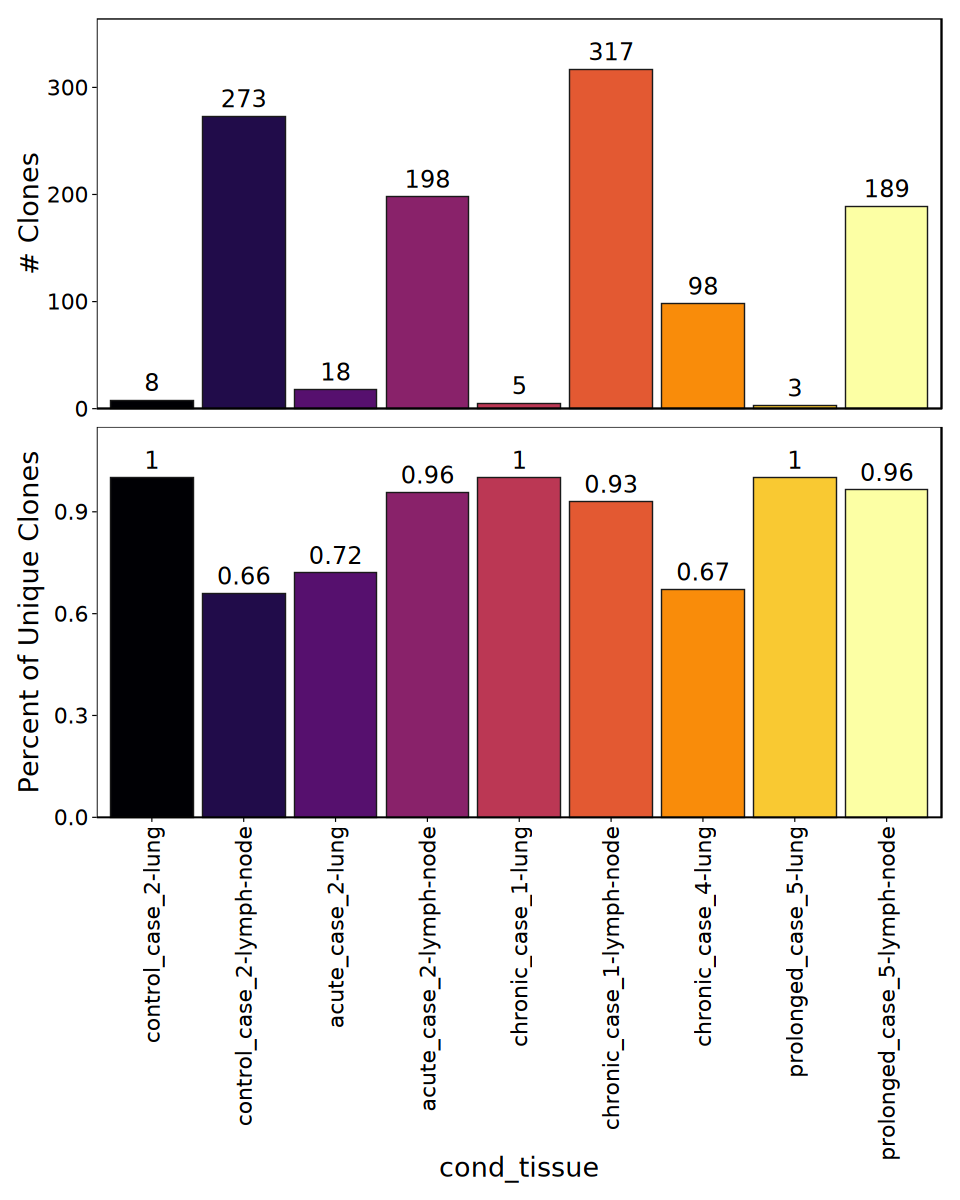

In [5]:
options(repr.plot.width = 8, repr.plot.height = 10, warn = -1)

clone_counts <- tcr_df %>%
    group_by(cond_tissue) %>%
    summarise(rows = n(), 
              clones = n_distinct(aaSeqCDR3),  
              prop = clones/rows,
              .groups = "drop")

cond_tissue_levels <- c("control_case_2-lung", "control_case_2-lymph-node", "acute_case_2-lung", "acute_case_2-lymph-node", "chronic_case_1-lung", 
                        "chronic_case_1-lymph-node", "chronic_case_4-lung", "prolonged_case_5-lung", "prolonged_case_5-lymph-node")

clone_counts <- clone_counts %>%
    mutate(cond_tissue = factor(cond_tissue, levels = cond_tissue_levels))

p1 <- ggplot(clone_counts, aes(x = cond_tissue, y = clones, fill = cond_tissue)) +
    geom_col(color = "grey10", linewidth = 0.3) +
    geom_text(aes(label = clones), vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_counts$clones) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = viridis::inferno(9)) +
    labs(y = "# Clones") +
    theme_linedraw() +
    theme(legend.position = "none",
          panel.grid = element_blank(),
          text = element_text(size = 16),
          axis.text.x = element_blank(),
          axis.title.x = element_blank(),
          axis.ticks.x = element_blank())

p2 <- ggplot(clone_counts, aes(x = cond_tissue, y = prop, fill = cond_tissue)) +
    geom_col(color = "grey10", linewidth = 0.3) +
    geom_text(aes(label = round(prop, 2), y = prop), vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_counts$prop) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = viridis::inferno(9)) +
    labs(y = "Percent of Unique Clones") +
    theme_linedraw() +
    theme(legend.position = "none",
          panel.grid = element_blank(),
          text = element_text(size = 16),
          axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

ggsave("~/SP-COVID/visium/2-analysis/TCR/out/plots/clone_counts_1.svg", plot = p1 / p2, width = 8, height = 10)
p1 / p2

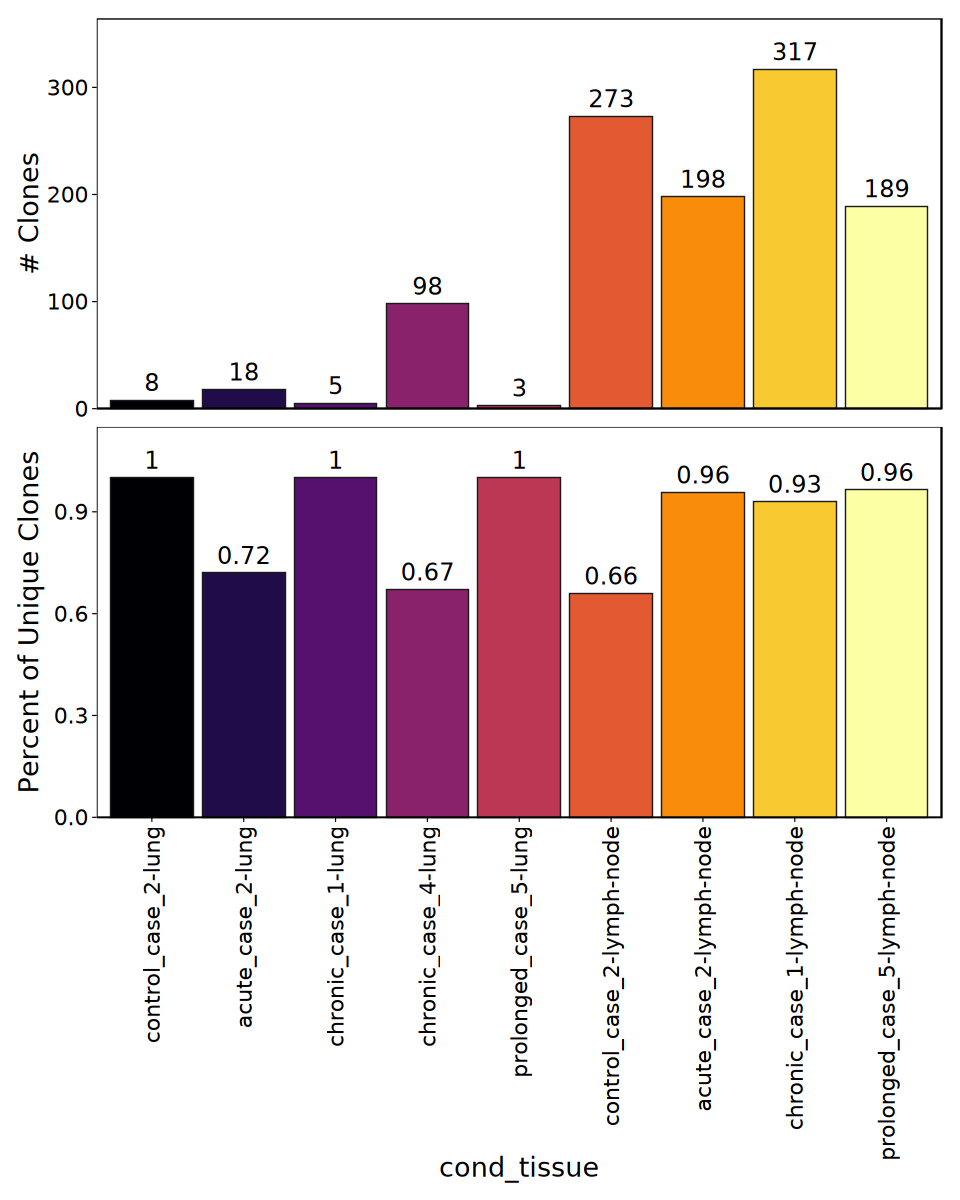

In [6]:
cond_tissue_levels <- c("control_case_2-lung", "acute_case_2-lung", "chronic_case_1-lung", "chronic_case_4-lung", "prolonged_case_5-lung",
                        "control_case_2-lymph-node", "acute_case_2-lymph-node", "chronic_case_1-lymph-node",  "prolonged_case_5-lymph-node")

clone_counts <- clone_counts %>%
    mutate(cond_tissue = factor(cond_tissue, levels = cond_tissue_levels))

p1 <- ggplot(clone_counts, aes(x = cond_tissue, y = clones, fill = cond_tissue)) +
    geom_col(color = "grey10", linewidth = 0.3) +
    geom_text(aes(label = clones), vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_counts$clones) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = viridis::inferno(9)) +
    labs(y = "# Clones") +
    theme_linedraw() +
    theme(legend.position = "none",
          panel.grid = element_blank(),
          text = element_text(size = 16),
          axis.text.x = element_blank(),
          axis.title.x = element_blank(),
          axis.ticks.x = element_blank())

p2 <- ggplot(clone_counts, aes(x = cond_tissue, y = prop, fill = cond_tissue)) +
    geom_col(color = "grey10", linewidth = 0.3) +
    geom_text(aes(label = round(prop, 2), y = prop), vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_counts$prop) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = viridis::inferno(9)) +
    labs(y = "Percent of Unique Clones") +
    theme_linedraw() +
    theme(legend.position = "none",
          panel.grid = element_blank(),
          text = element_text(size = 16),
          axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

ggsave("~/SP-COVID/visium/2-analysis/TCR/out/plots/clone_counts_2.svg", plot = p1 / p2, width = 8, height = 10)
p1 / p2

We can do the same by tissue, we can see that we have more unique clonotyes in lymph-nodes compared to lungs.

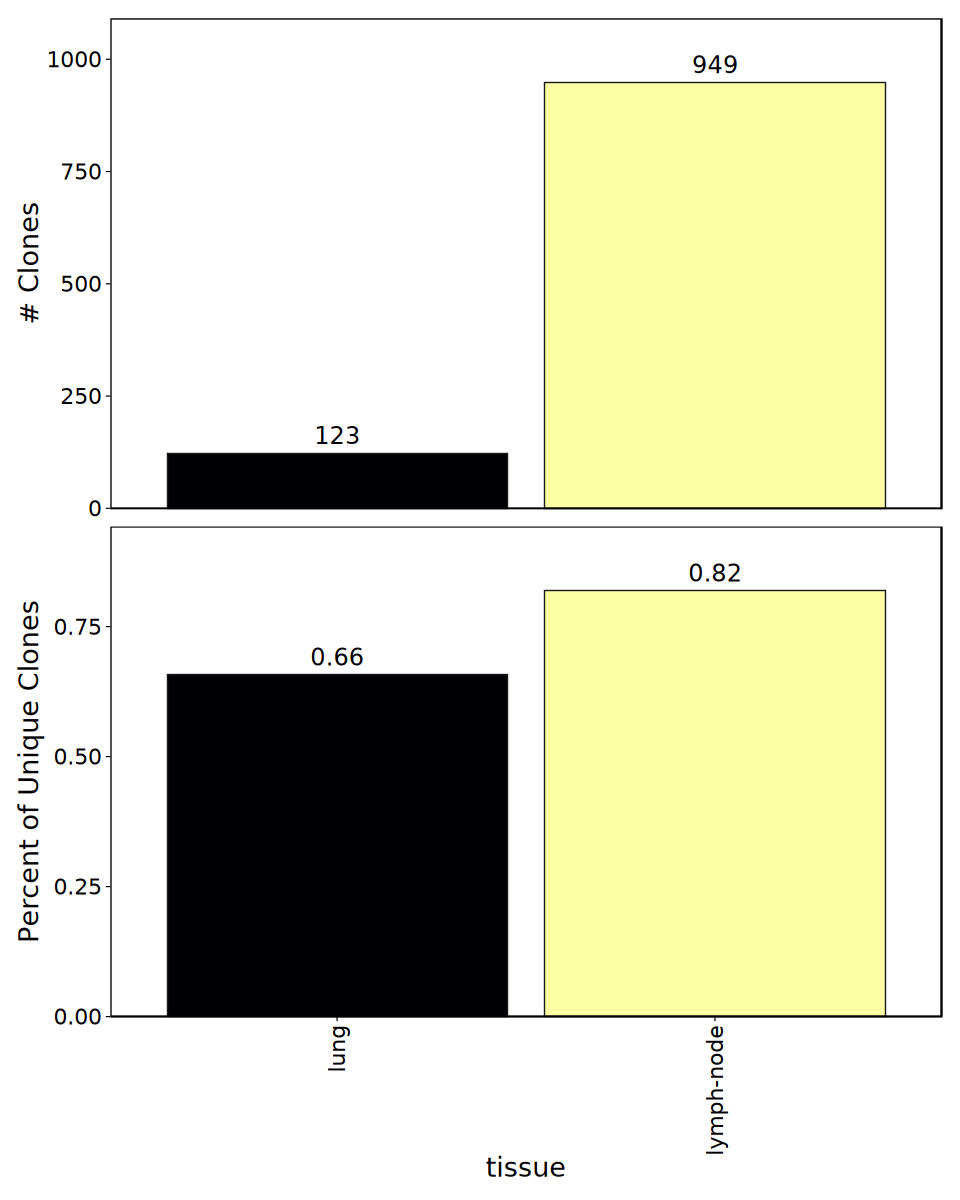

In [7]:
options(repr.plot.width = 8, repr.plot.height = 10, warn = -1)

clone_counts <- tcr_df %>%
    group_by(tissue) %>%
    summarise(rows = n(), 
              clones = n_distinct(aaSeqCDR3),  
              prop = clones/rows,
              .groups = "drop")

p1 <- ggplot(clone_counts, aes(x = tissue, y = clones, fill = tissue)) +
    geom_col(color = "grey10", linewidth = 0.3) +
    geom_text(aes(label = clones), vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_counts$clones) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = viridis::inferno(2)) +
    labs(y = "# Clones") +
    theme_linedraw() +
    theme(legend.position = "none",
          text = element_text(size = 16),
          panel.grid = element_blank(),
          axis.text.x = element_blank(),
          axis.title.x = element_blank(),
          axis.ticks.x = element_blank())

p2 <- ggplot(clone_counts, aes(x = tissue, y = prop, fill = tissue)) +
    geom_col(color = "grey10", linewidth = 0.3) +
    geom_text(aes(label = round(prop, 2), y = prop), vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_counts$prop) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = viridis::inferno(2)) +
    labs(y = "Percent of Unique Clones") +
    theme_linedraw() +
    theme(legend.position = "none",
          panel.grid = element_blank(),
          text = element_text(size = 16),
          axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

p1 / p2

Finally, we can also check it by disease stage.

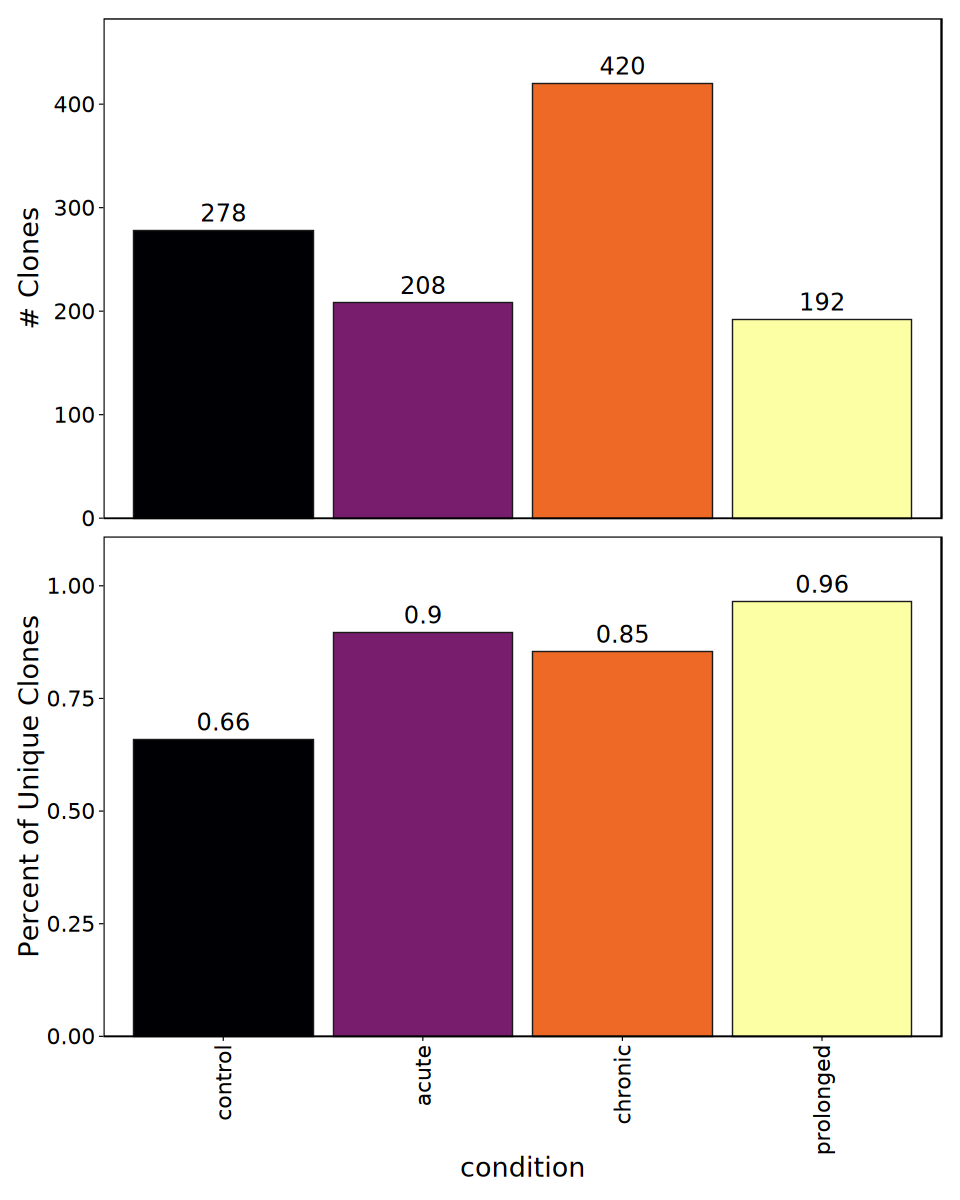

In [8]:
options(repr.plot.width = 8, repr.plot.height = 10, warn = -1)

clone_counts <- tcr_df %>%
    group_by(condition) %>%
    summarise(rows = n(), 
              clones = n_distinct(aaSeqCDR3),  
              prop = clones/rows,
              .groups = "drop")

condition_levels <- c("control", "acute", "chronic", "prolonged")

clone_counts <- clone_counts %>%
    mutate(condition = factor(condition, levels = condition_levels))

p1 <- ggplot(clone_counts, aes(x = condition, y = clones, fill = condition)) +
    geom_col(color = "grey10", linewidth = 0.3) +
    geom_text(aes(label = clones), vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_counts$clones) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = viridis::inferno(4)) +
    labs(y = "# Clones") +
    theme_linedraw() +
    theme(legend.position = "none",
          text = element_text(size = 16),
          panel.grid = element_blank(),
          axis.text.x = element_blank(),
          axis.title.x = element_blank(),
          axis.ticks.x = element_blank())

p2 <- ggplot(clone_counts, aes(x = condition, y = prop, fill = condition)) +
    geom_col(color = "grey10", linewidth = 0.3) +
    geom_text(aes(label = round(prop, 2), y = prop), vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_counts$prop) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = viridis::inferno(4)) +
    labs(y = "Percent of Unique Clones") +
    theme_linedraw() +
    theme(legend.position = "none",
          panel.grid = element_blank(),
          text = element_text(size = 16),
          axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

p1 / p2

We can also explore the distribution of UMI counts for each sample (Look at how many UMIs we detect for each cloneID by sample).

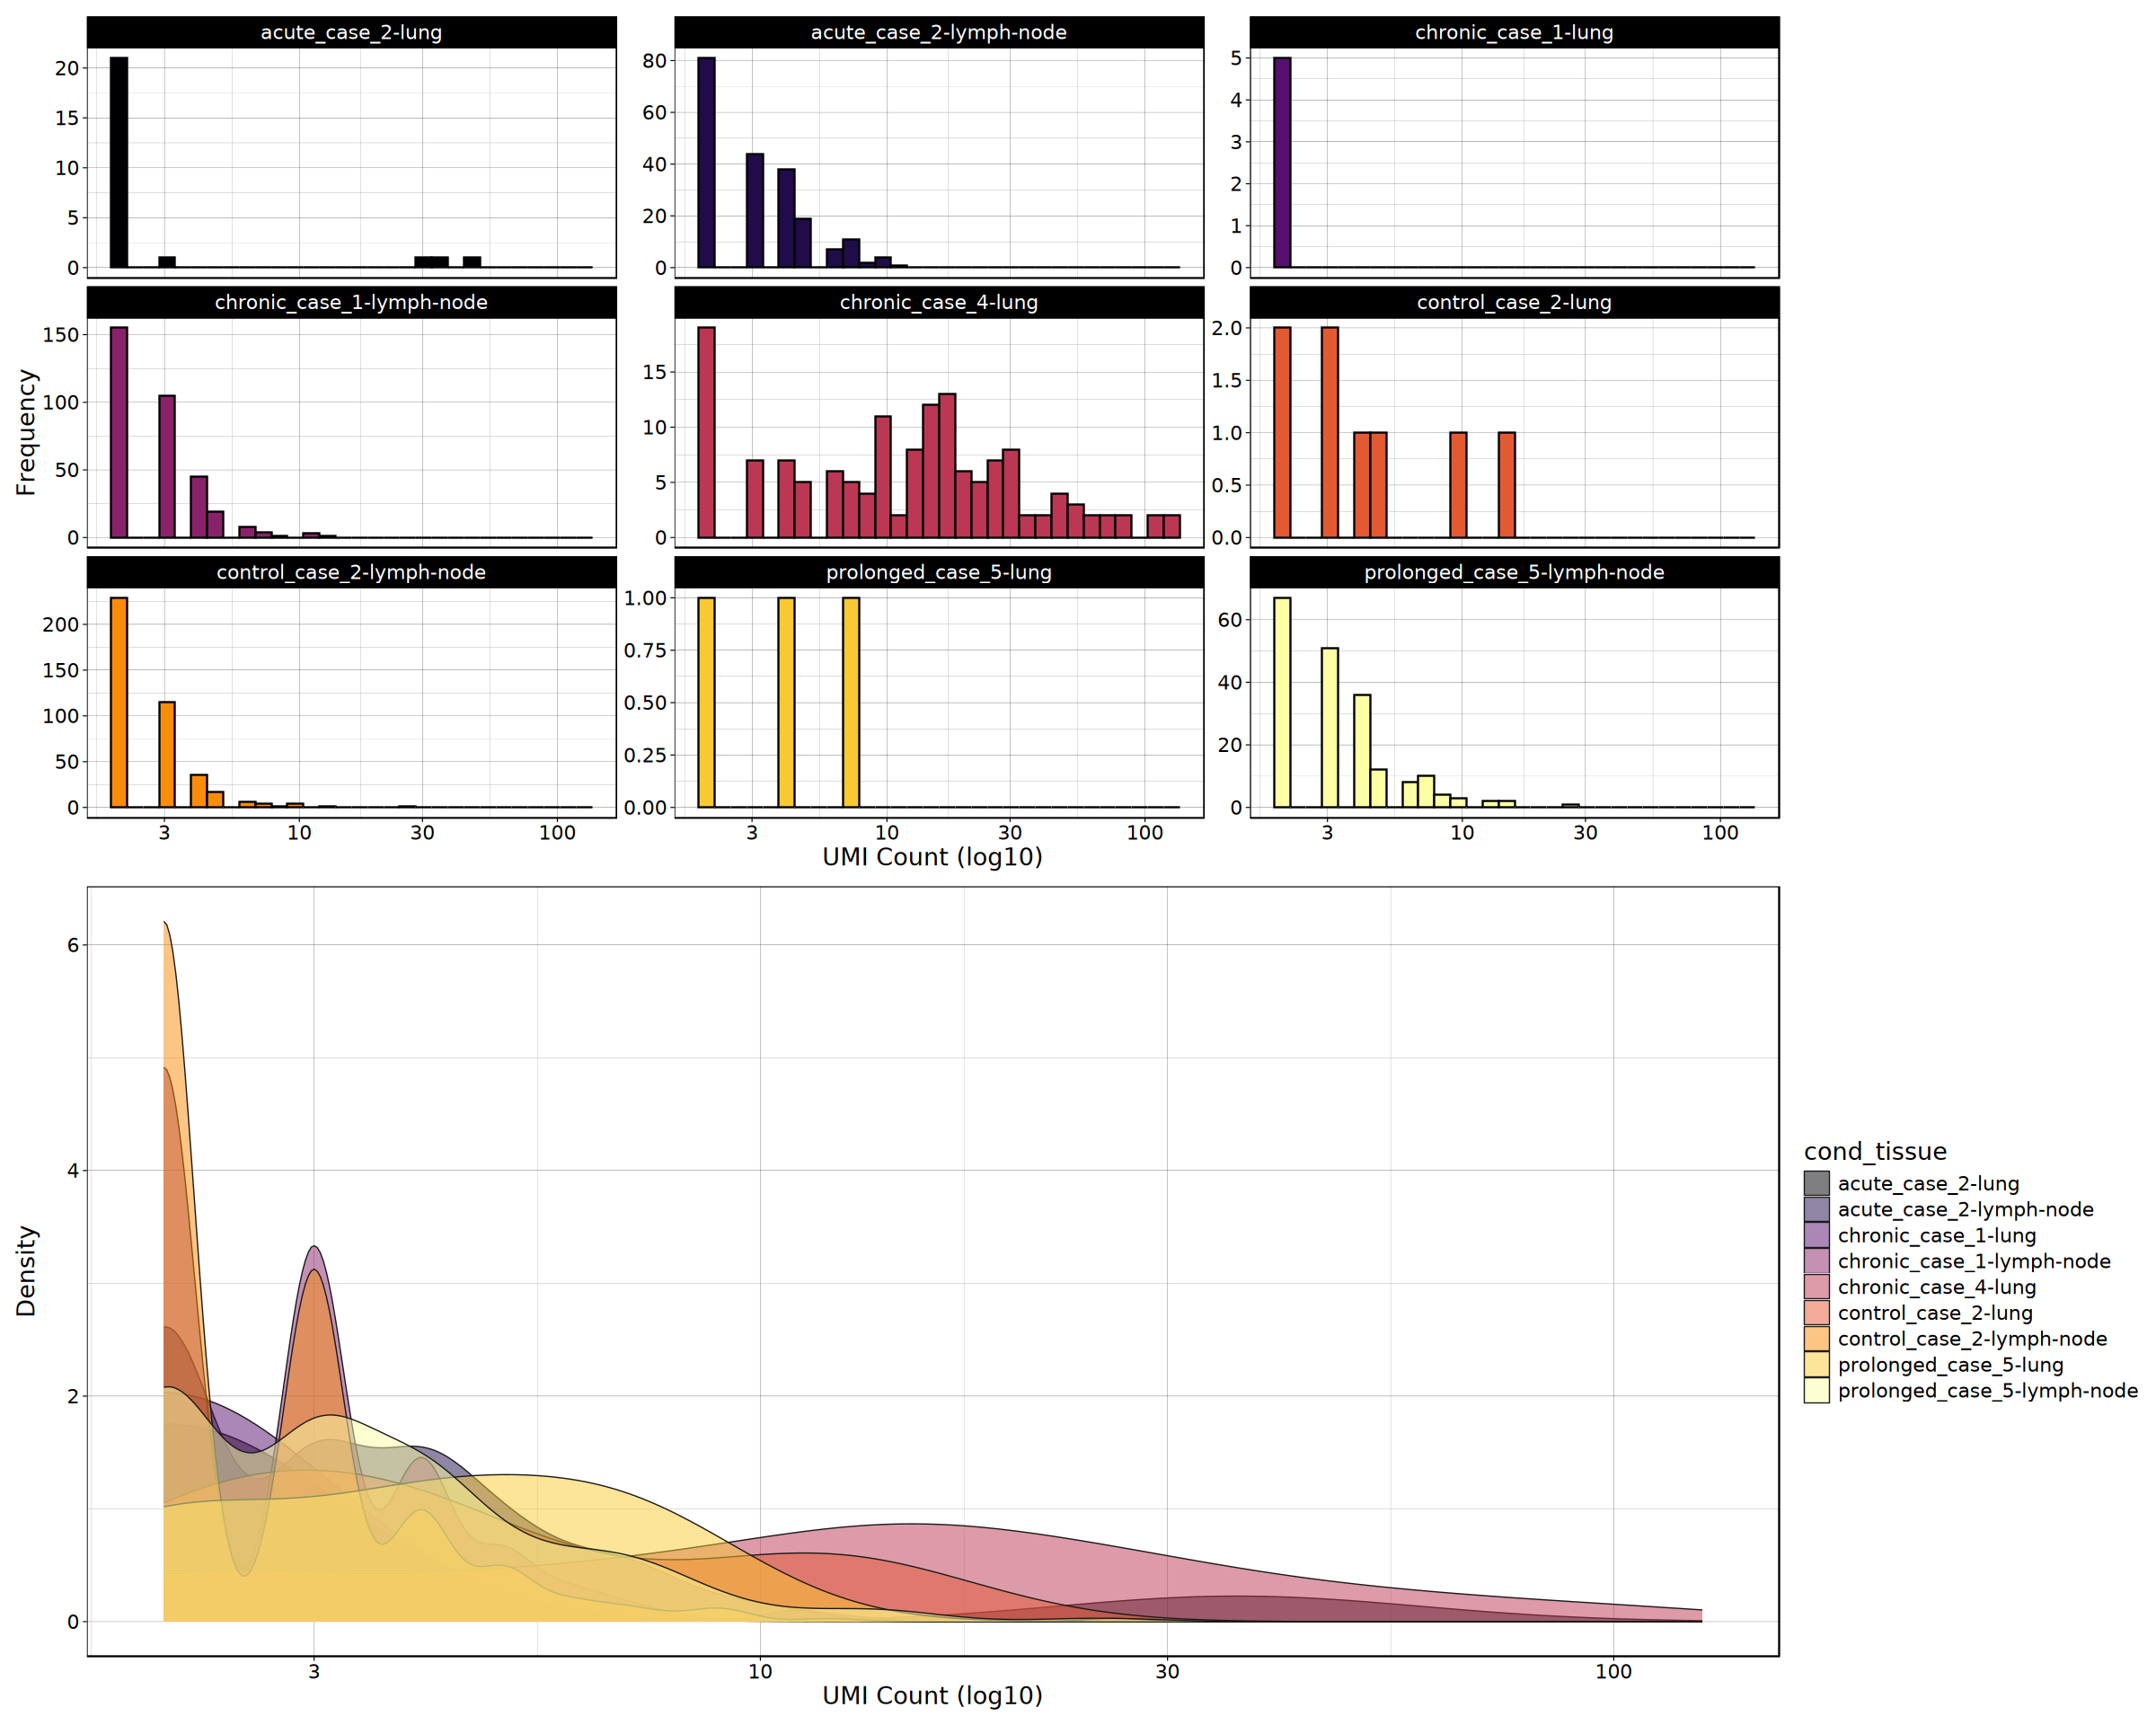

In [9]:
options(repr.plot.width = 20, repr.plot.height = 16, warn = -1)

p1 <- ggplot(tcr_df, aes(x = uniqueMoleculeCount, fill = cond_tissue)) +
    geom_histogram(bins = 30, color = "black") +
    scale_fill_manual(values = viridis::inferno(9)) +
    scale_x_log10() +
    facet_wrap(~cond_tissue, scales = "free_y") +
    labs(x = "UMI Count (log10)", y = "Frequency") +
    theme_linedraw() +
    theme(legend.position = "none",
          text = element_text(size = 16))

p2 <- ggplot(tcr_df, aes(x = uniqueMoleculeCount, fill = cond_tissue)) +
    geom_density(alpha = 0.5, color = "grey10", linewidth = 0.3) +
    scale_fill_manual(values = viridis::inferno(9)) +
    scale_x_log10() +
    labs(x = "UMI Count (log10)",  y = "Density") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          legend.position = "right")

p1 / p2

Next, we can explore the distribution of sequence lengths by looking at the length distribution of the CDR3 amino acid sequences by chain, and both together. 

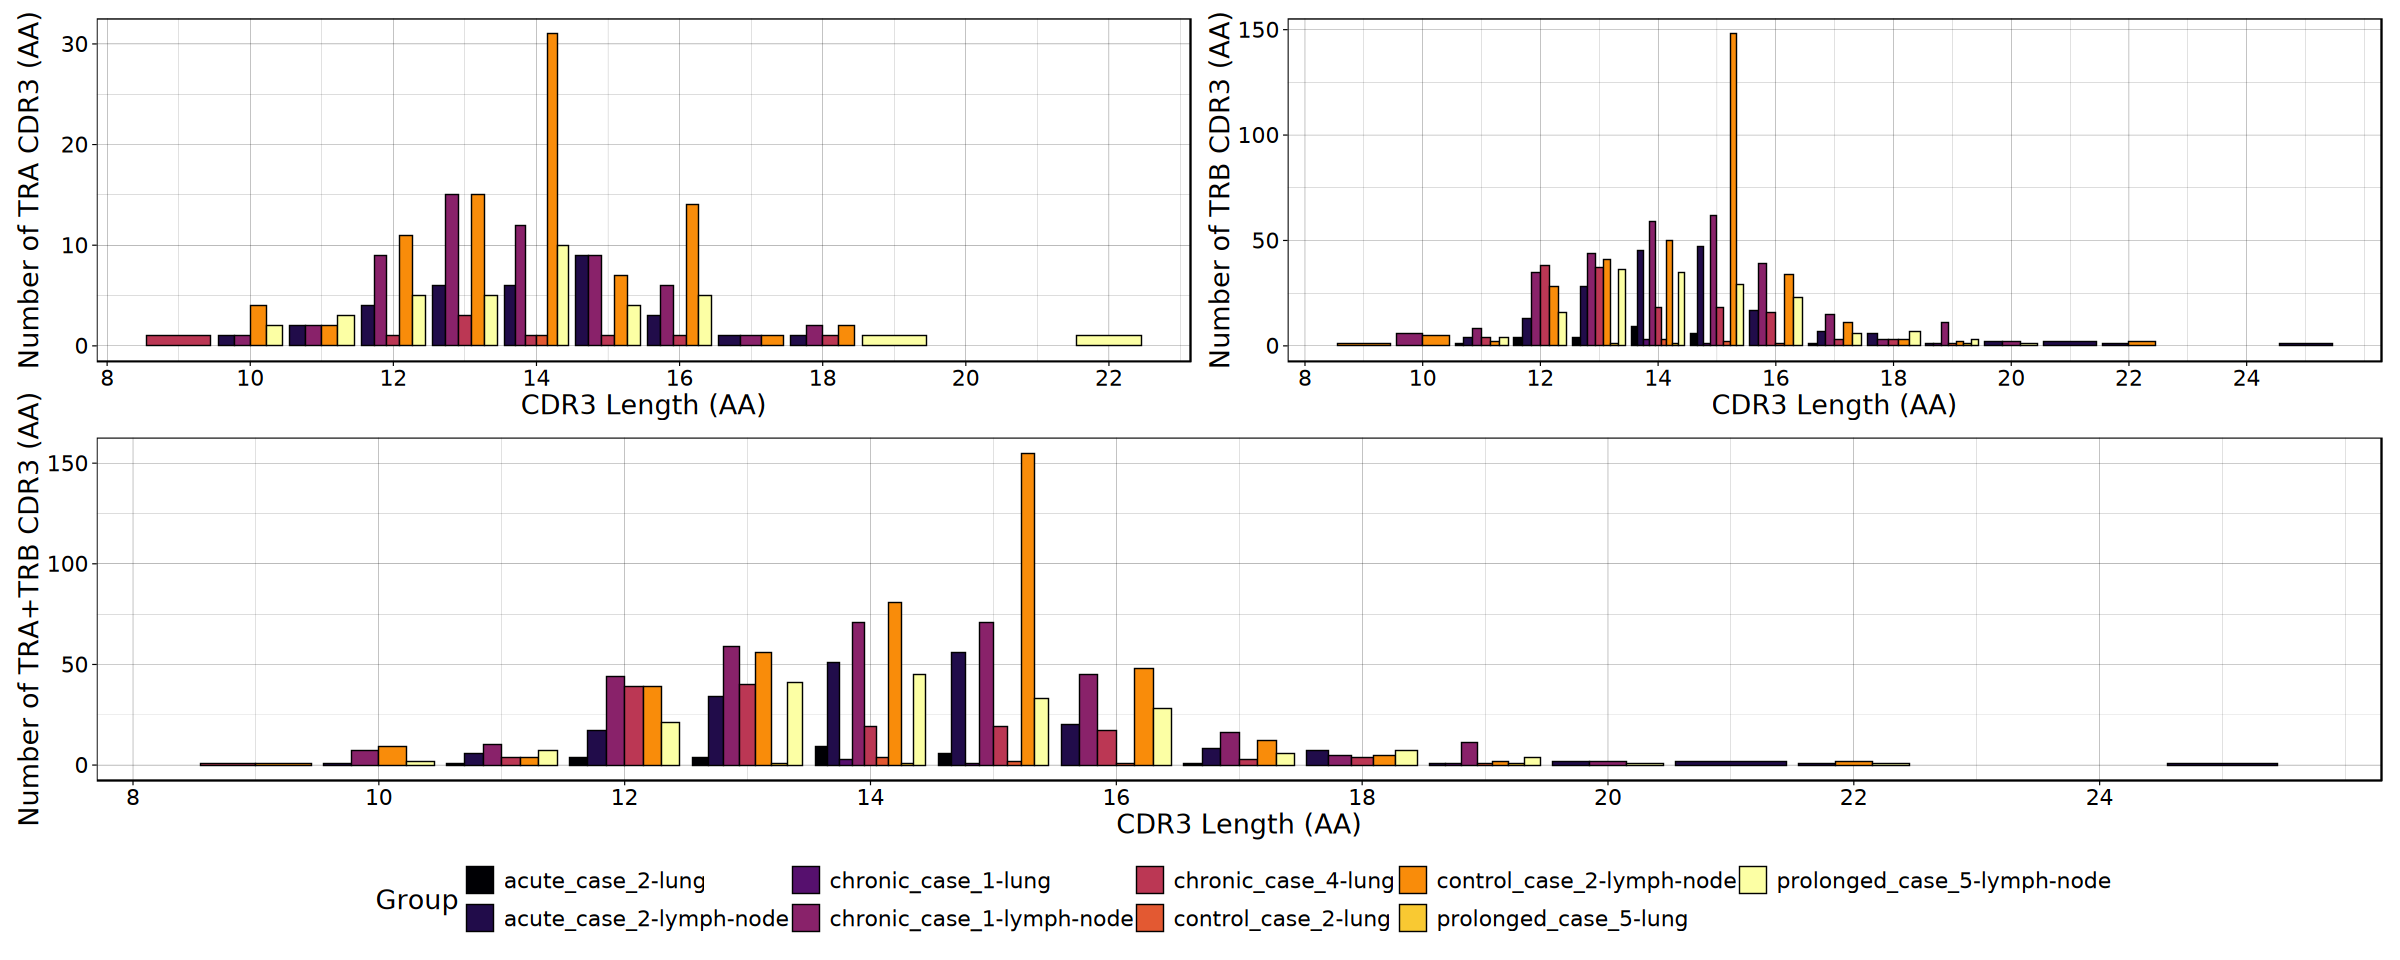

In [10]:
options(repr.plot.width = 20, repr.plot.height = 8, warn = -1)

tcr_df <- tcr_df %>%
  mutate(chain = case_when(str_detect(allVHitsWithScore, "TRAV") ~ "TRA",
                           str_detect(allVHitsWithScore, "TRBV") ~ "TRB",
                           TRUE ~ "unknown"),
         cdr3_length = nchar(as.character(aaSeqCDR3)))

sample_colors <- setNames(viridis::inferno(n_distinct(tcr_df$cond_tissue)),
                          sort(unique(tcr_df$cond_tissue)))

p1 <- tcr_df %>%
  filter(chain == "TRA") %>%
  group_by(cond_tissue, cdr3_length) %>%
  summarise(count = n(), .groups = "drop") %>%
  ggplot(aes(x = cdr3_length, y = count, fill = cond_tissue)) +
  geom_bar(stat = "identity", position = "dodge", color = "black", linewidth = 0.3) +
  scale_x_continuous(breaks = seq(0, max(tcr_df$cdr3_length, na.rm = TRUE), by = 2)) +
  scale_fill_manual(values = sample_colors) +
  labs(x = "CDR3 Length (AA)", y = "Number of TRA CDR3 (AA)", fill = "Group") +
  theme_linedraw() +
  theme(legend.position = "none",
        text = element_text(size = 16))

p2 <- tcr_df %>%
  filter(chain == "TRB") %>%
  group_by(cond_tissue, cdr3_length) %>%
  summarise(count = n(), .groups = "drop") %>%
  ggplot(aes(x = cdr3_length, y = count, fill = cond_tissue)) +
  geom_bar(stat = "identity", position = "dodge", color = "black", linewidth = 0.3) +
  scale_x_continuous(breaks = seq(0, max(tcr_df$cdr3_length, na.rm = TRUE), by = 2)) +
  scale_fill_manual(values = sample_colors) +
  labs(x = "CDR3 Length (AA)", y = "Number of TRB CDR3 (AA)", fill = "Group") +
  theme_linedraw() +
  theme(legend.position = "none",
        text = element_text(size = 16))

p3 <- tcr_df %>%
  filter(chain %in% c("TRA", "TRB")) %>%
  group_by(cond_tissue, cdr3_length) %>%
  summarise(count = n(), .groups = "drop") %>%
  ggplot(aes(x = cdr3_length, y = count, fill = cond_tissue)) +
  geom_bar(stat = "identity", position = "dodge", color = "black", linewidth = 0.3) +
  scale_x_continuous(breaks = seq(0, max(tcr_df$cdr3_length, na.rm = TRUE), by = 2)) +
  scale_fill_manual(values = sample_colors) +
  labs(x = "CDR3 Length (AA)", y = "Number of TRA+TRB CDR3 (AA)", fill = "Group") +
  theme_linedraw() +
  theme(legend.position = "bottom",
        text = element_text(size = 16))

(p1 | p2) / p3

## Repertoires summary

To summarize CDR3 sequence composition, we will analyze the relative amino-acid usage across all TRB CDR3 sequences. We will quantify the proportion of each amino acid across the repertoire, providing a global view of biochemical constraints and selection acting on the antigen-recognition region. This will provide us insights into the amino acid composition and variability at each residue, which can be indicative of functional constraints or selection pressures on the CDR3.

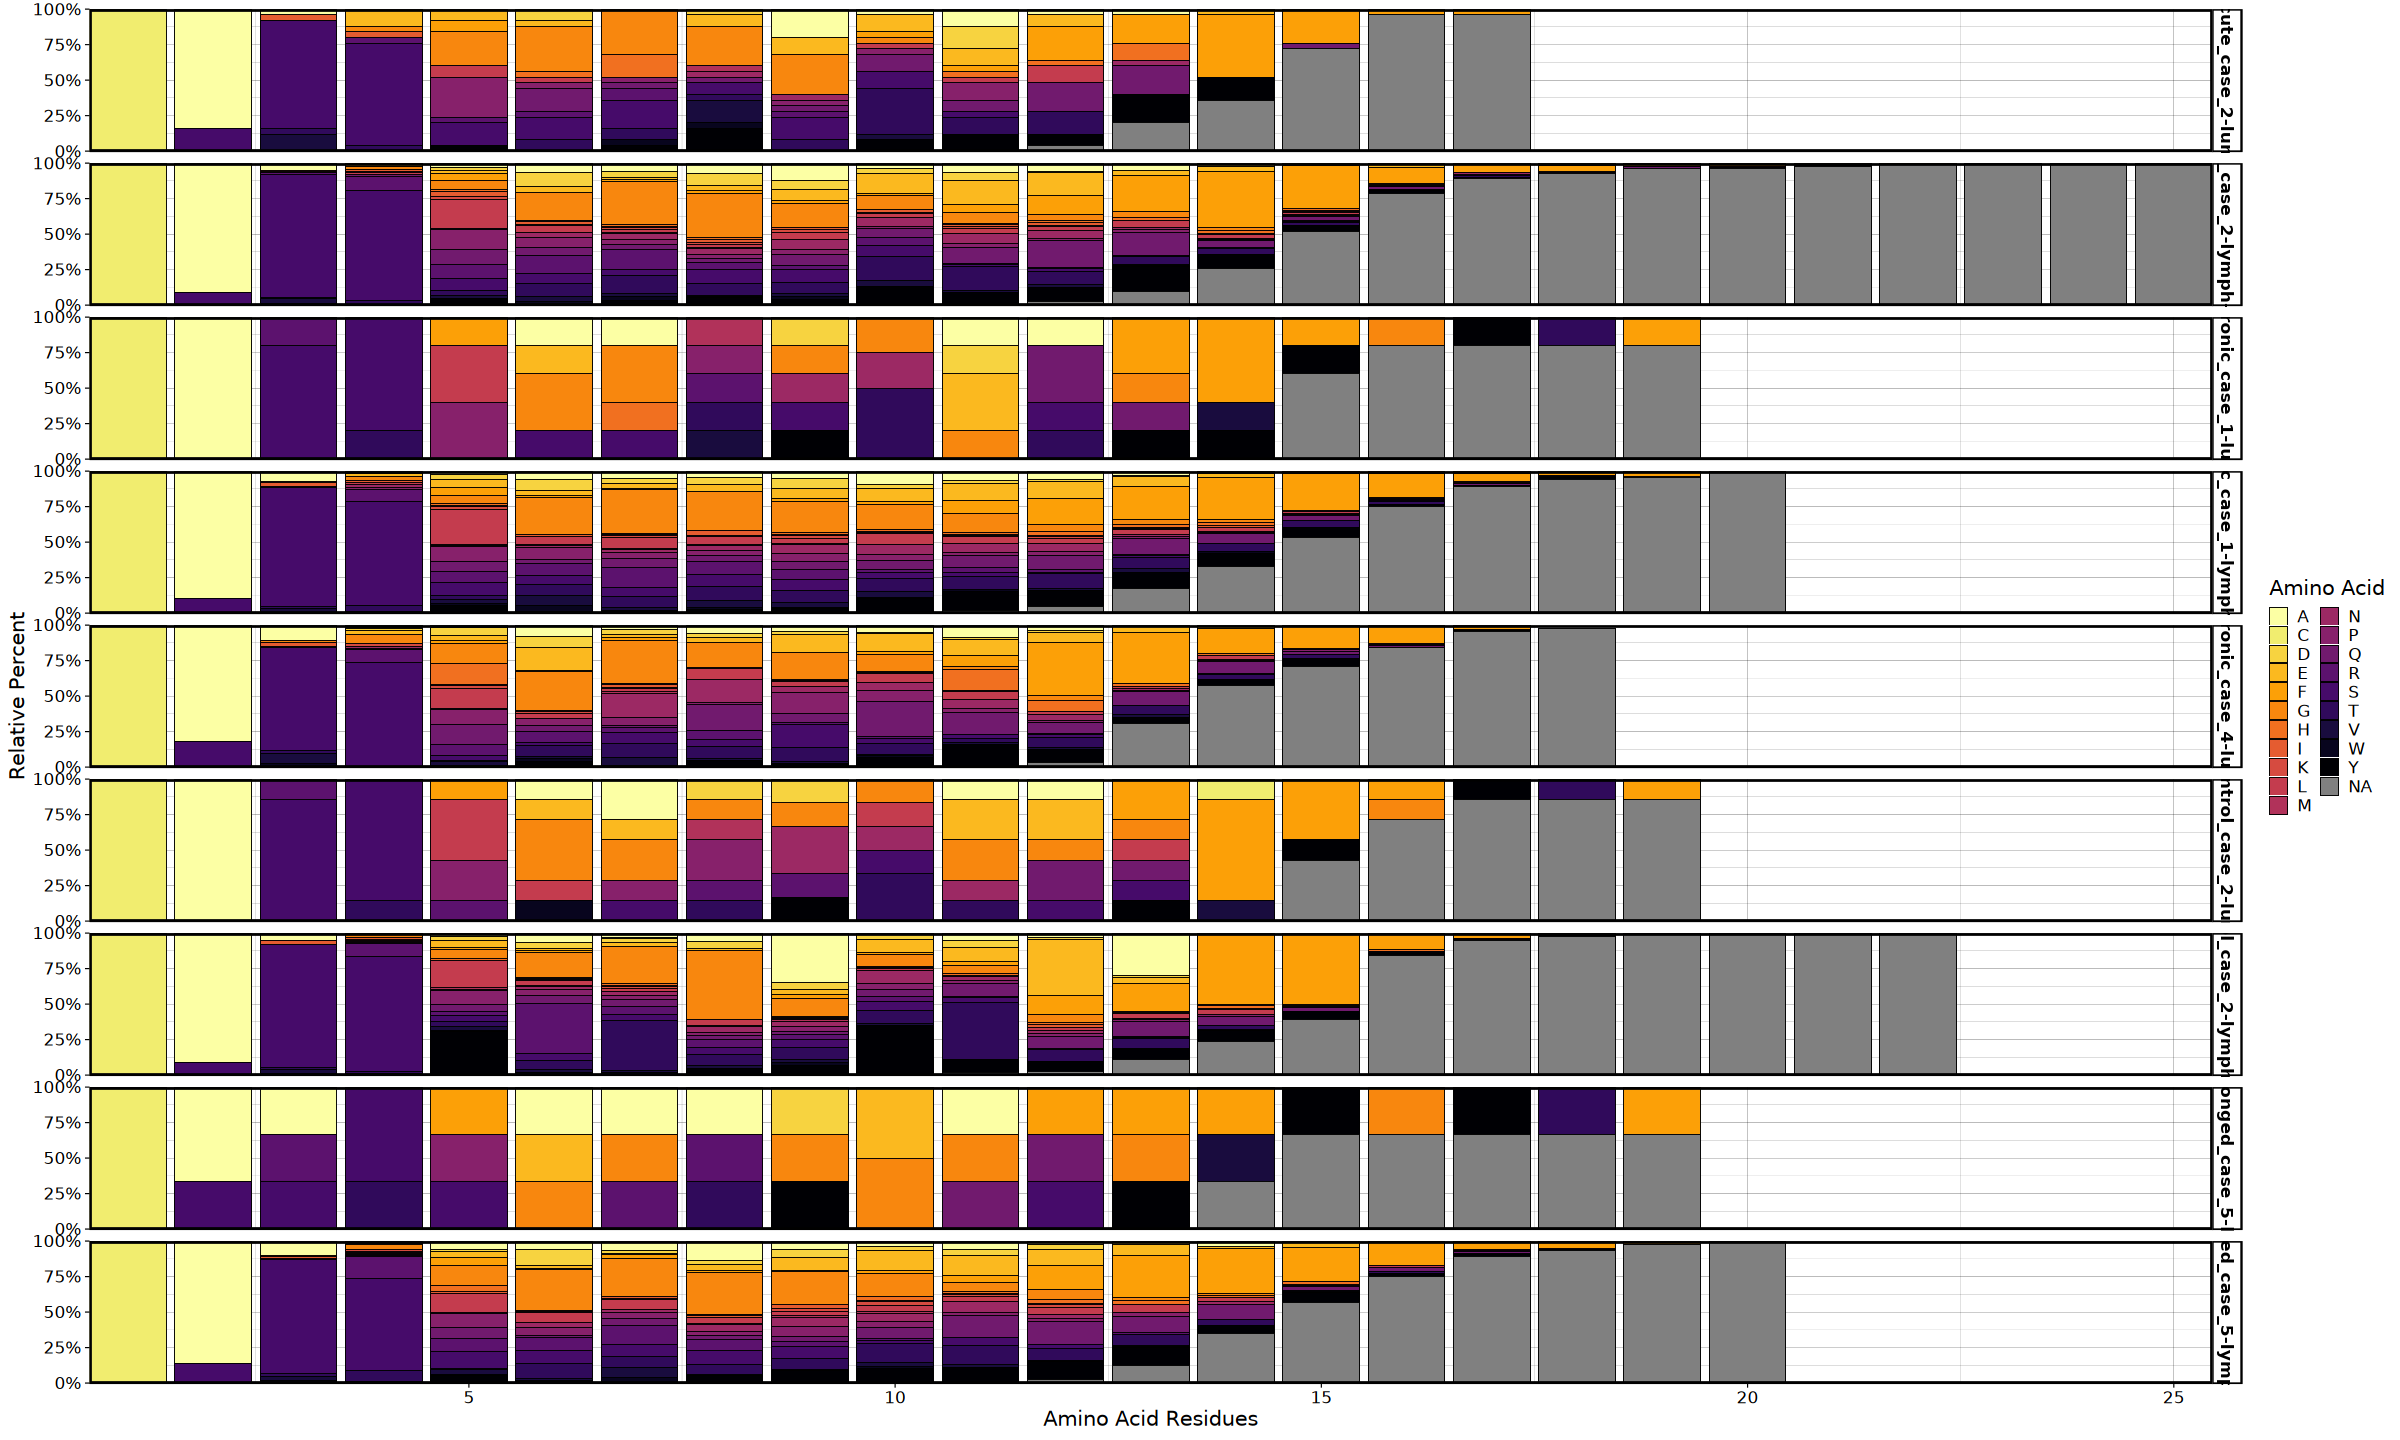

In [11]:
options(repr.plot.width = 20, repr.plot.height = 12, warn = -1)

trb_data <- tcr_df %>% 
  filter(chain == "TRB" & !is.na(aaSeqCDR3) & aaSeqCDR3 != "")

calculate_aa_frequencies_by_sample <- function(df) {
    # Function to calculate amino acid frequencies per position for each sample
    all_aa <- c("A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y", "NA")
      
    results_list <- list()
    global_max_length <- max(nchar(as.character(df$aaSeqCDR3)), na.rm = TRUE)
      
    for (sample in unique(df$cond_tissue)) {
        sample_seqs <- df %>% 
            filter(cond_tissue == sample) %>% 
            pull(aaSeqCDR3)
        
        n_seqs <- length(sample_seqs)
        
        aa_matrix <- matrix(0, nrow = length(all_aa), ncol = global_max_length, 
                            dimnames = list(all_aa, paste0("Pos", 1:global_max_length)))
        
        for (seq in sample_seqs) {
            if (!is.na(seq) && seq != "") {
                seq_chars <- strsplit(as.character(seq), "")[[1]]
                seq_length <- length(seq_chars)
            
            for (pos in 1:global_max_length) {
              if (pos <= seq_length) {
                aa <- seq_chars[pos]
                
                if (aa %in% all_aa[1:20]) {  
                  aa_matrix[aa, pos] <- aa_matrix[aa, pos] + 1
                }
              } else {
                aa_matrix["NA", pos] <- aa_matrix["NA", pos] + 1
              }
            }
          }
        }
        
        aa_freq <- sweep(aa_matrix, 2, colSums(aa_matrix), FUN = "/") * 100
        aa_freq[is.nan(aa_freq)] <- 0
        
        aa_freq_long <- as.data.frame(aa_freq) %>%
          tibble::rownames_to_column("amino_acid") %>%
          pivot_longer(cols = starts_with("Pos"), 
                       names_to = "position", 
                       values_to = "percentage") %>%
          mutate(position = as.numeric(gsub("Pos", "", position)),
                 sample = sample)
        
        positions_to_keep <- aa_freq_long %>%
          group_by(position) %>%
          summarise(has_aa = sum(percentage[amino_acid != "NA"]) > 0, .groups = "drop") %>%
          filter(has_aa) %>%
          pull(position)
        
        aa_freq_long <- aa_freq_long %>%
          filter(position %in% positions_to_keep) %>%
          filter(percentage > 0) 
        
        results_list[[sample]] <- aa_freq_long
    }
    results <- bind_rows(results_list)
    return(results)
}

aa_freq_data <- calculate_aa_frequencies_by_sample(trb_data)

aa_order <- c("A", "C", "D", "E", "F", "G", "H", "I", "K", "L", 
              "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y", "NA")
aa_freq_data$amino_acid <- factor(aa_freq_data$amino_acid, levels = aa_order)

inferno_cols <- viridis(20, option = "inferno", direction = -1)
names(inferno_cols) <- aa_order[1:20]
inferno_cols["NA"] <- "#808080" 

ggplot(aa_freq_data, aes(x = position, y = percentage/100, fill = amino_acid)) +
    geom_bar(stat = "identity", position = "stack", color = "black", linewidth = 0.2) +
    scale_fill_manual(values = inferno_cols, name = "Amino Acid") +
    scale_y_continuous(labels = scales::percent_format(), 
                       expand = c(0, 0), limits = c(0, 1)) +
    scale_x_continuous(breaks = function(x) unique(floor(pretty(x))), expand = c(0, 0)) +
    facet_wrap(~sample, ncol = 1, strip.position = "right") +
    labs(x = "Amino Acid Residues",  y = "Relative Percent") +
    theme_linedraw() +
    theme(text = element_text(size = 12),
          strip.background = element_rect(fill = "white", color = "black"),
          strip.text = element_text(size = 10, face = "bold", color = "black"),
          panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
          panel.spacing = unit(0.5, "lines"),
          legend.position = "right",
          legend.key.size = unit(0.4, "cm"),
          axis.text.x = element_text(size = 10),
          axis.text.y = element_text(size = 10))

We can also visualize the relative usage of TCR genes. First we can take a look on the V gene locus usage across samples.

In [12]:
tcr_gene <- tcr_df %>%
    mutate(v_gene = str_extract(allVHitsWithScore, "TR[AB]V[^\\(]*"),
           j_gene = str_extract(allJHitsWithScore, "TR[AB]J[^\\(]*")) %>%
    filter(!is.na(v_gene), !is.na(j_gene))

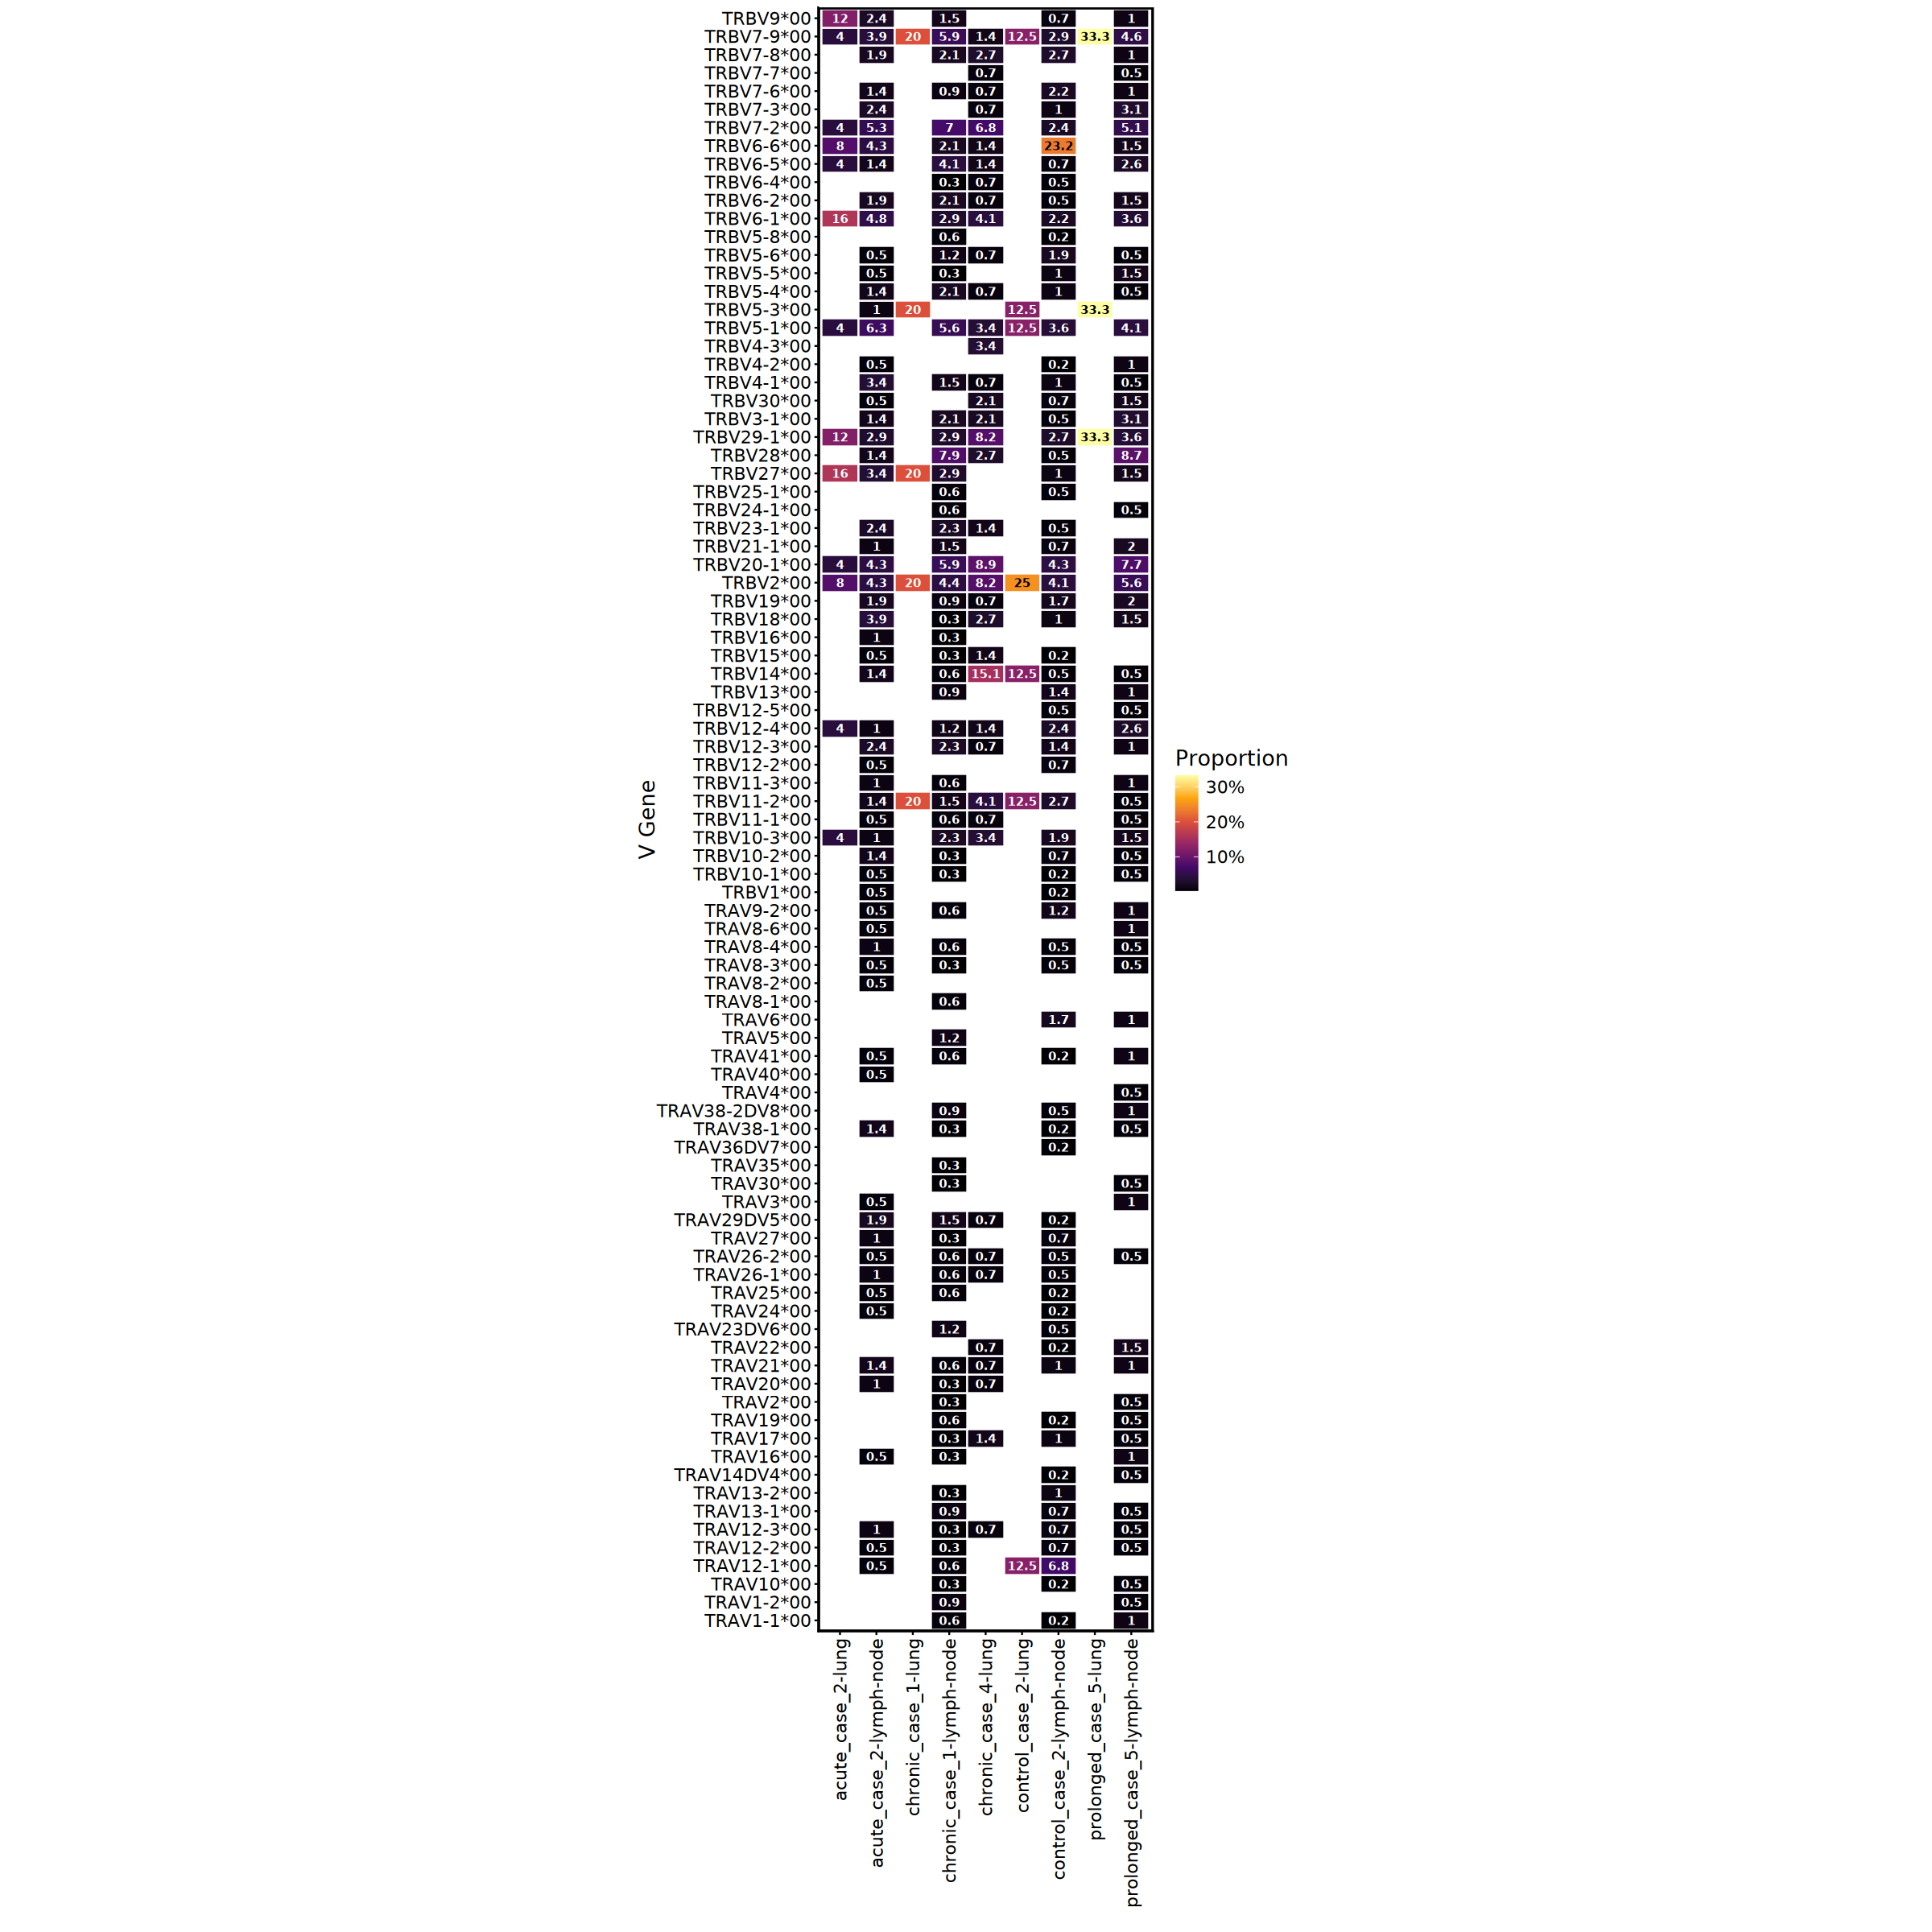

In [13]:
options(repr.plot.width = 20, repr.plot.height = 20, warn = -1)

tcr_gene %>%
  group_by(cond_tissue, v_gene) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(cond_tissue) %>%
  mutate(proportion = count / sum(count)) %>%
  ungroup() %>%
  mutate(text_color = ifelse(proportion > 0.2, "black", "white")) %>%
  ggplot(aes(x = cond_tissue, y = v_gene, fill = proportion)) +
  geom_tile(color = "white", linewidth = 0.5) +
  geom_text(aes(label = round(proportion * 100, 1), color = text_color), 
            fontface = "bold", size = 3) +
  scale_fill_viridis_c(option = "inferno", name = "Proportion",
                       labels = scales::percent_format()) +
  scale_color_identity() +
  labs(x = "", y = "V Gene") +
  theme_classic() +
  theme(text = element_text(size = 16),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
        plot.title = element_text(hjust = 0.5, face = "bold"),
        panel.background = element_rect(fill = "white")) +
  coord_fixed(ratio = 0.5)

Next, we can examine the J gene locus usage across samples examining gene pairings.

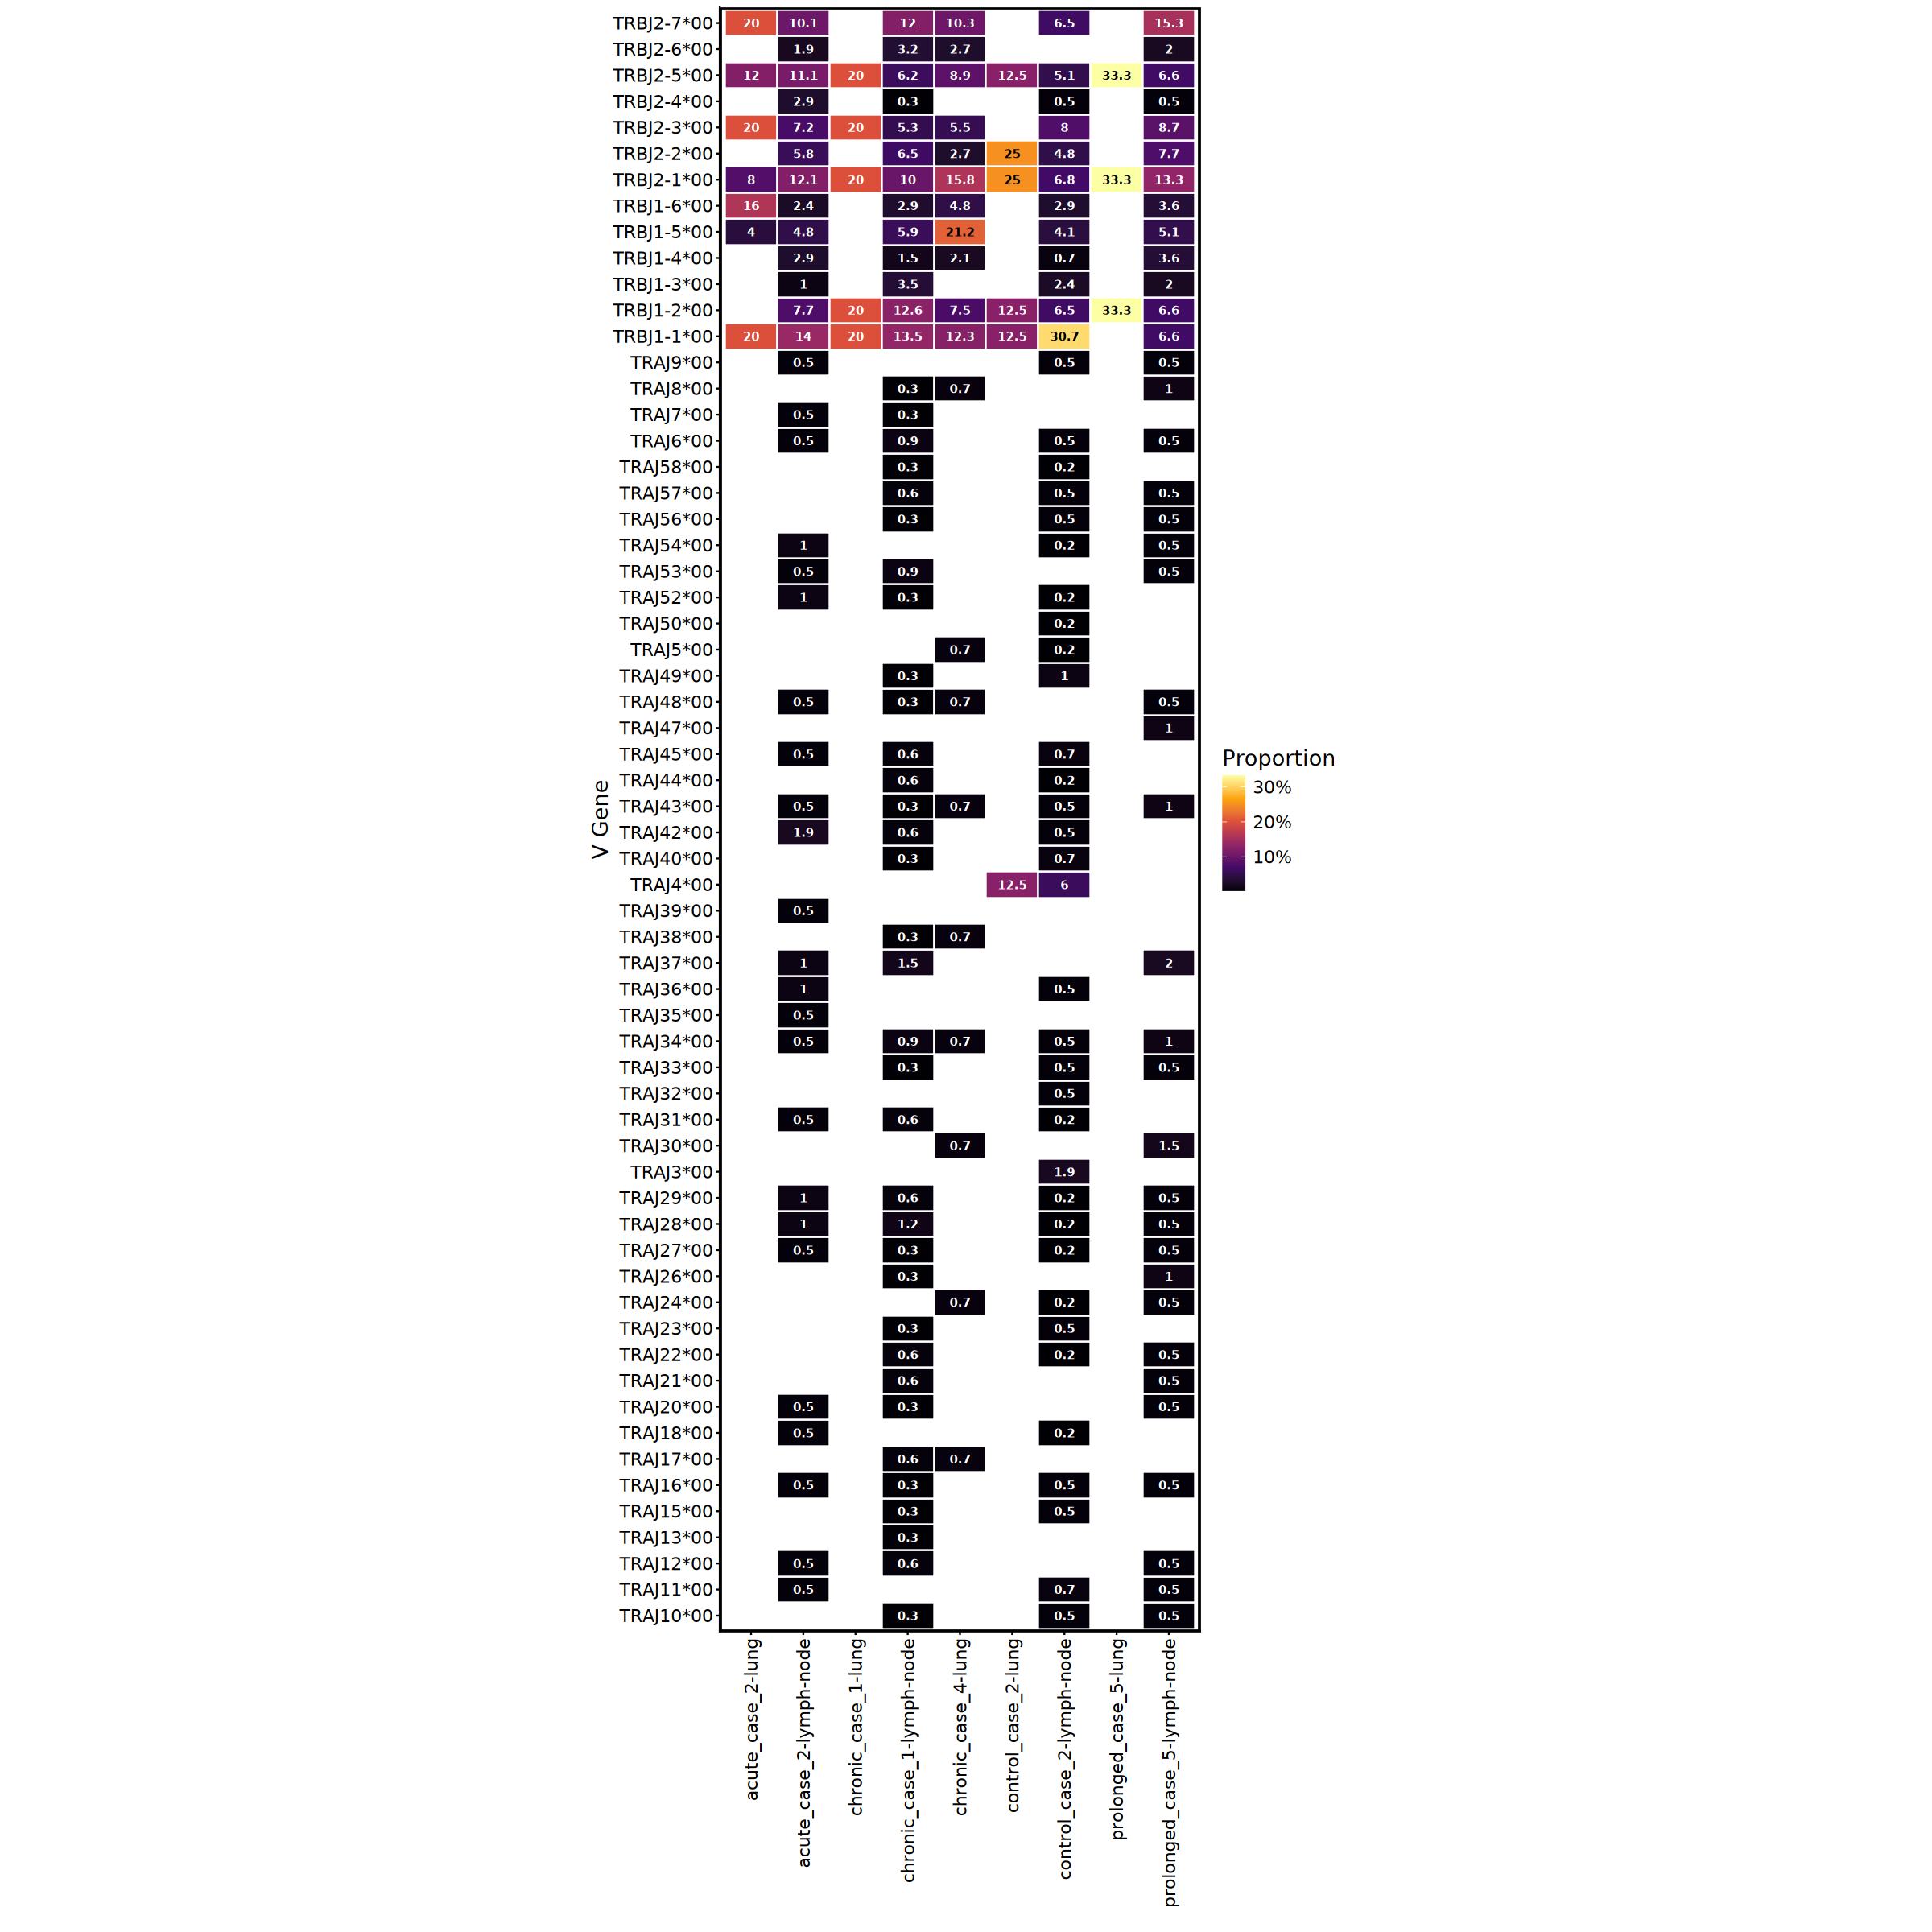

In [14]:
options(repr.plot.width = 20, repr.plot.height = 20, warn = -1)

tcr_gene %>%
  group_by(cond_tissue, j_gene) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(cond_tissue) %>%
  mutate(proportion = count / sum(count)) %>%
  ungroup() %>%
  mutate(text_color = ifelse(proportion > 0.2, "black", "white")) %>%
  ggplot(aes(x = cond_tissue, y = j_gene, fill = proportion)) +
  geom_tile(color = "white", linewidth = 0.5) +
  geom_text(aes(label = round(proportion * 100, 1), color = text_color), 
            fontface = "bold", size = 3) +
  scale_fill_viridis_c(option = "inferno", name = "Proportion",
                       labels = scales::percent_format()) +
  scale_color_identity() +
  labs(x = "", y = "V Gene") +
  theme_classic() +
  theme(text = element_text(size = 16),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
        plot.title = element_text(hjust = 0.5, face = "bold"),
        panel.background = element_rect(fill = "white")) +
  coord_fixed(ratio = 0.5)

We can also explore which are the most common V-J gene pairings and how many times are they found.

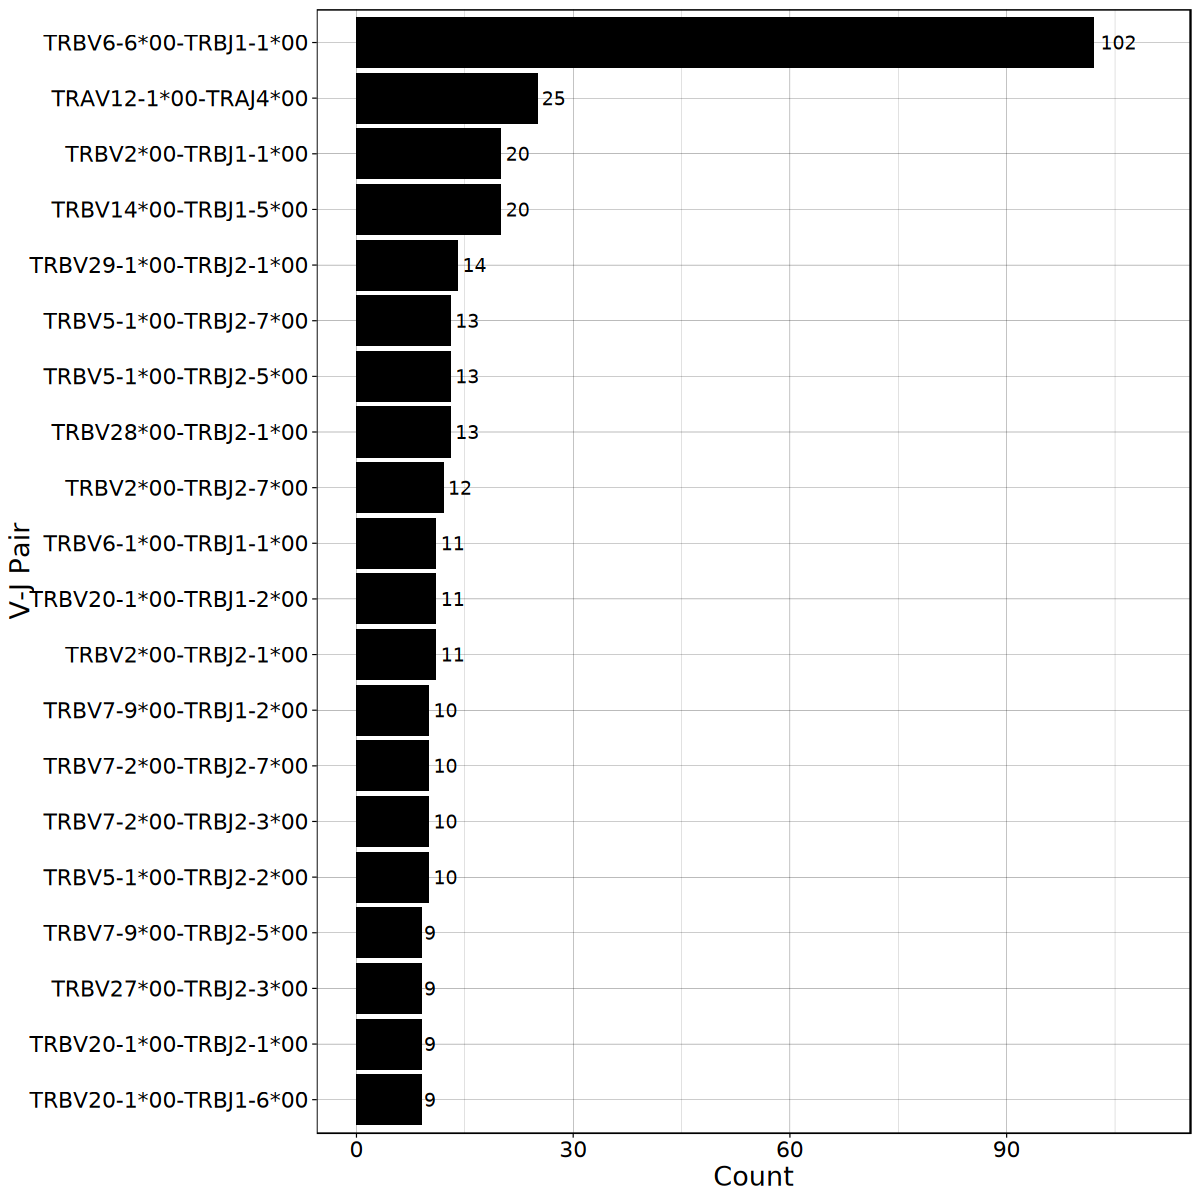

In [15]:
options(repr.plot.width = 10, repr.plot.height = 10, warn = -1)

tcr_gene %>%
    group_by(v_gene, j_gene) %>%
    summarise(count = n(), .groups = "drop") %>%
    arrange(desc(count)) %>%
    slice_head(n = 20) %>%
    mutate(vj_pair = paste(v_gene, j_gene, sep = "-")) %>%
    
    ggplot(aes(x = reorder(vj_pair, count), y = count)) +
    geom_bar(stat = "identity", fill = "black") +
    geom_text(aes(label = count), hjust = -0.2) +
    coord_flip() +
    scale_y_continuous(limits = c(0, 110)) +
    labs(x = "V-J Pair", y = "Count") +
    theme_linedraw() +
    theme(text = element_text(size = 16))

## Clonal dynamics

First, we will check for the exact number of overlapping clones between all samples and the Morisita’s overlap index. Morisita’s overlap index is a frequency-weighted metric that strongly emphasizes abundant clonotypes while being robust to differences in sampling depth. It reflects the probability that two randomly drawn sequences, one from each repertoire, belong to the same clonotype. Morisita’s index is particularly well-suited for comparing biological similarity driven by dominant clonal expansions.

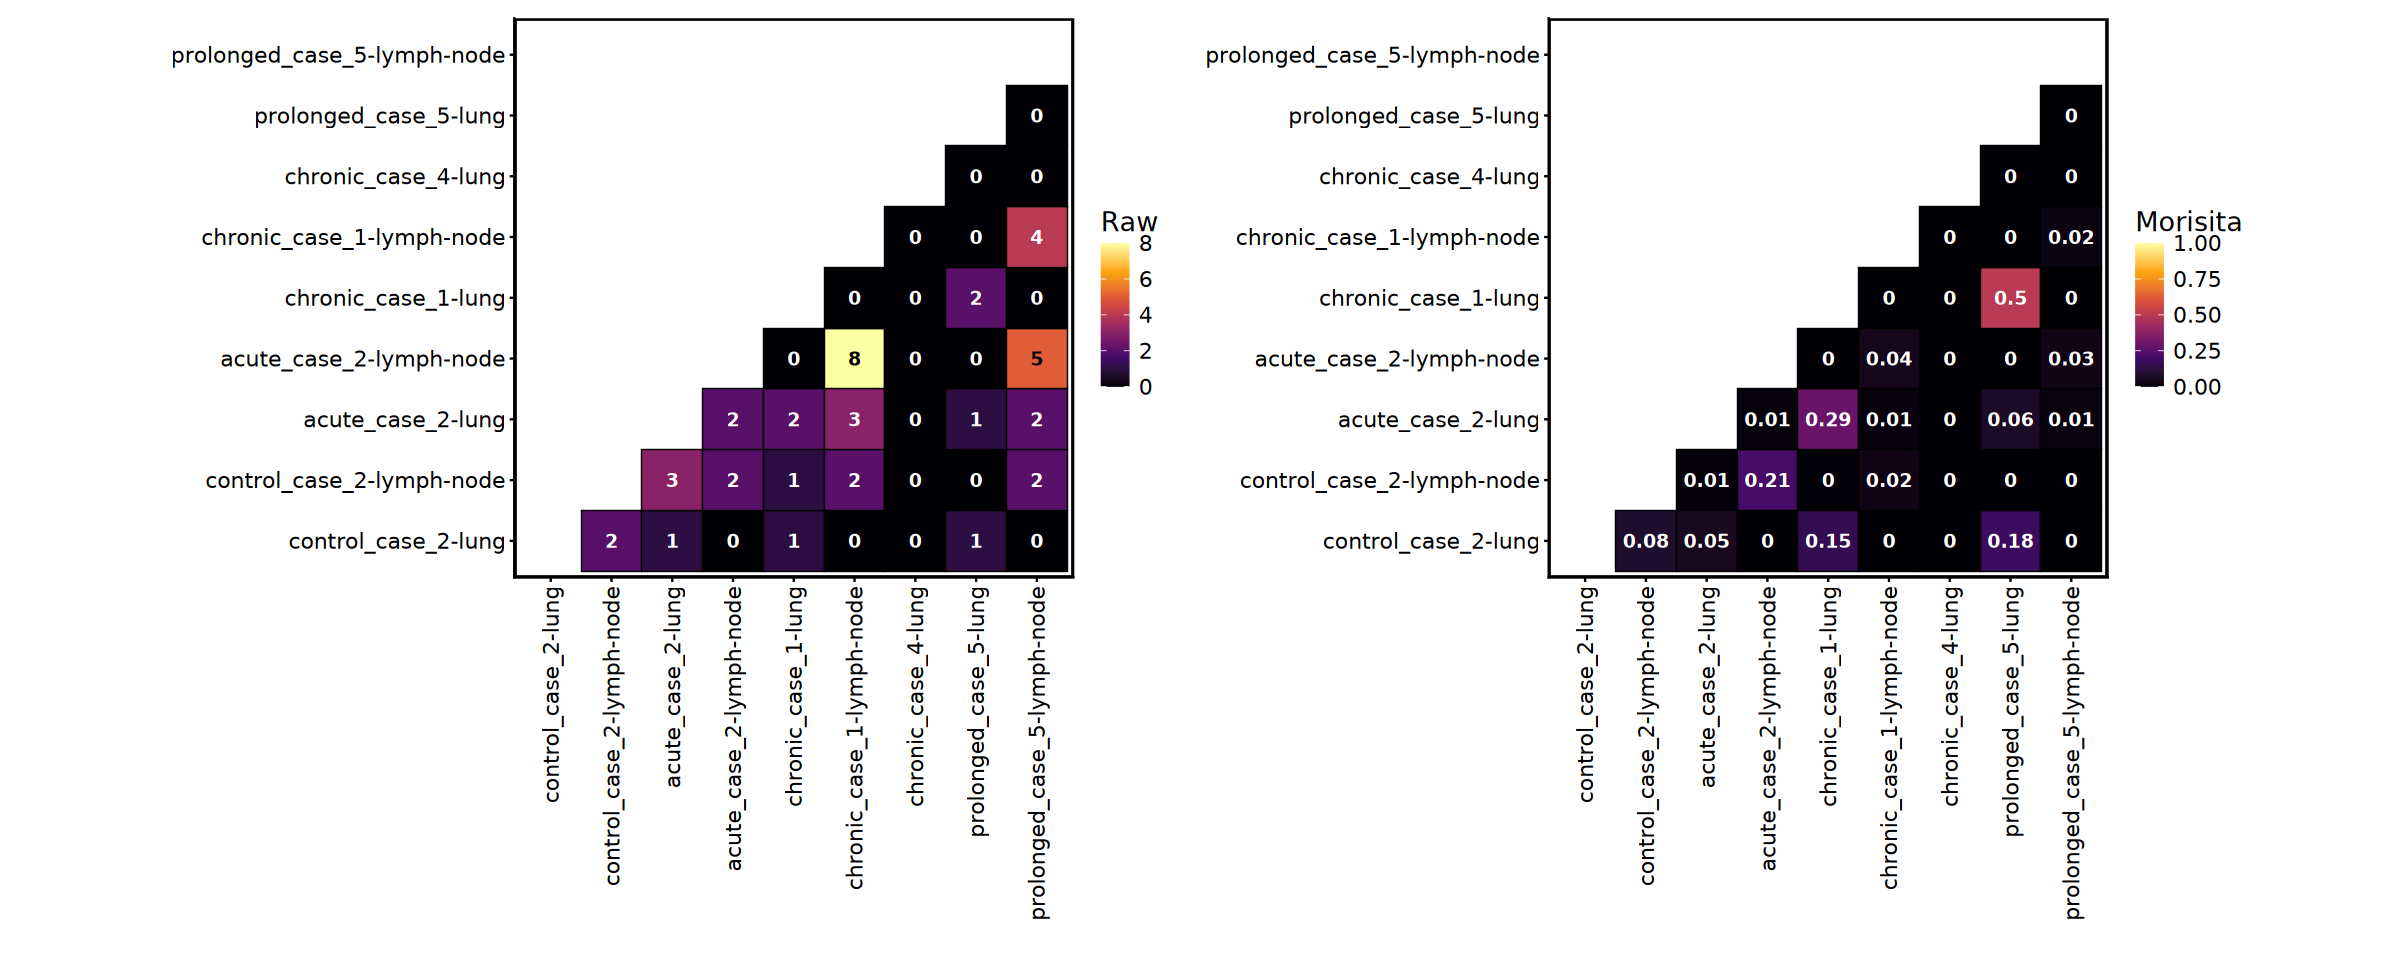

In [16]:
options(repr.plot.width = 20, repr.plot.height = 8, warn = -1)

samples <- unique(tcr_df$cond_tissue)
n_samples <- length(samples)
raw_matrix <- matrix(NA, nrow = n_samples, ncol = n_samples,
                     dimnames = list(samples, samples))

for (i in 1:(n_samples-1)) {
  for (j in (i+1):n_samples) {
    clones_i <- tcr_df %>% filter(cond_tissue == samples[i]) %>% pull(cloneID2) %>% unique()
    clones_j <- tcr_df %>% filter(cond_tissue == samples[j]) %>% pull(cloneID2) %>% unique()
    raw_matrix[i, j] <- length(intersect(clones_i, clones_j))
  }
}

morisita_matrix <- matrix(NA, nrow = n_samples, ncol = n_samples,
                          dimnames = list(samples, samples))

for (i in 1:(n_samples-1)) {
  for (j in (i+1):n_samples) {
    freq_i <- tcr_df %>% filter(cond_tissue == samples[i]) %>% 
      group_by(cloneID2) %>% summarise(count = n(), .groups = "drop")
    freq_j <- tcr_df %>% filter(cond_tissue == samples[j]) %>% 
      group_by(cloneID2) %>% summarise(count = n(), .groups = "drop")
    
    merged <- full_join(freq_i, freq_j, by = "cloneID2", suffix = c("_i", "_j"))
    merged[is.na(merged)] <- 0
    
    n_i <- sum(merged$count_i)
    n_j <- sum(merged$count_j)
    
    if (n_i > 0 && n_j > 0) {
      lambda_i <- sum(merged$count_i^2) / (n_i^2)
      lambda_j <- sum(merged$count_j^2) / (n_j^2)
      morisita_matrix[i, j] <- 2 * sum(merged$count_i * merged$count_j) / ((lambda_i + lambda_j) * n_i * n_j)
    }
  }
}

raw_data <- as.data.frame(raw_matrix) %>%
  tibble::rownames_to_column("sample1") %>%
  pivot_longer(cols = -sample1, names_to = "sample2", values_to = "overlap") %>%
  mutate(sample1 = factor(sample1, levels = samples),
         sample2 = factor(sample2, levels = samples)) %>%
  filter(!is.na(overlap)) %>%
  mutate(text_color = ifelse(overlap > max(overlap, na.rm = TRUE) / 2, "black", "white"))
morisita_data <- as.data.frame(morisita_matrix) %>%
  tibble::rownames_to_column("sample1") %>%
  pivot_longer(cols = -sample1, names_to = "sample2", values_to = "overlap") %>%
  mutate(sample1 = factor(sample1, levels = samples),
         sample2 = factor(sample2, levels = samples)) %>%
  filter(!is.na(overlap)) %>%
  mutate(text_color = ifelse(overlap > 0.5, "black", "white"))

p1 <- ggplot(raw_data, aes(x = sample2, y = sample1, fill = overlap)) +
  geom_tile(color = "black", linewidth = 0.3) +
  geom_text(aes(label = round(overlap, 0), color = text_color), fontface = "bold") +
  scale_color_identity() +
  scale_fill_viridis_c(option = "inferno", name = "Raw", direction = 1) +
  scale_x_discrete(drop = FALSE) +
  scale_y_discrete(drop = FALSE) +
  labs(x = "", y = "") +
  theme_classic() +
  theme(text = element_text(size = 16),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
        plot.title = element_text(hjust = 0.5, face = "bold"),
        panel.background = element_rect(fill = "white")) +
  coord_fixed()

p2 <- ggplot(morisita_data, aes(x = sample2, y = sample1, fill = overlap)) +
  geom_tile(color = "black", linewidth = 0.3) +
  geom_text(aes(label = round(overlap, 2), color = text_color), fontface = "bold") +
  scale_color_identity() +
  scale_fill_viridis_c(option = "inferno", name = "Morisita", limits = c(0, 1), direction = 1) +
  scale_x_discrete(drop = FALSE) +
  scale_y_discrete(drop = FALSE) +
  labs(x = "", y = "") +
  theme_classic() +
  theme(text = element_text(size = 16),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
        plot.title = element_text(hjust = 0.5, face = "bold"),
        panel.background = element_rect(fill = "white")) +
  coord_fixed()

p1 | p2

We can also check the overlap of clonotypes by condition.

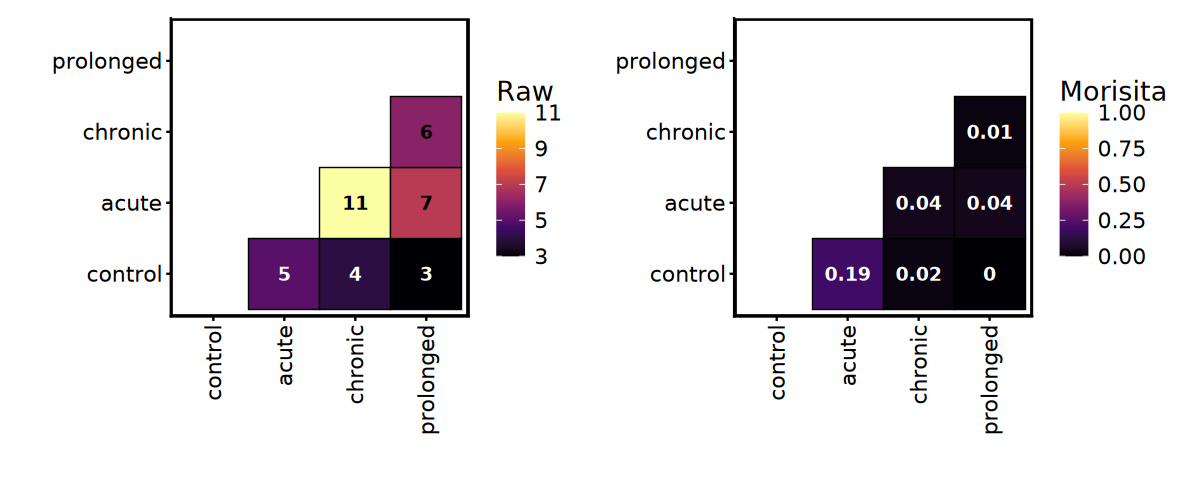

In [17]:
options(repr.plot.width = 10, repr.plot.height = 4, warn = -1)

samples <- unique(tcr_df$condition)
n_samples <- length(samples)

raw_matrix <- matrix(NA, nrow = n_samples, ncol = n_samples,
                     dimnames = list(samples, samples))

for (i in 1:(n_samples-1)) {
  for (j in (i+1):n_samples) {
    clones_i <- tcr_df %>% filter(condition == samples[i]) %>% pull(cloneID2) %>% unique()
    clones_j <- tcr_df %>% filter(condition == samples[j]) %>% pull(cloneID2) %>% unique()
    raw_matrix[i, j] <- length(intersect(clones_i, clones_j))
  }
}

morisita_matrix <- matrix(NA, nrow = n_samples, ncol = n_samples,
                          dimnames = list(samples, samples))

for (i in 1:(n_samples-1)) {
  for (j in (i+1):n_samples) {
    freq_i <- tcr_df %>% filter(condition == samples[i]) %>% 
      group_by(cloneID2) %>% summarise(count = n(), .groups = "drop")
    freq_j <- tcr_df %>% filter(condition == samples[j]) %>% 
      group_by(cloneID2) %>% summarise(count = n(), .groups = "drop")
    
    merged <- full_join(freq_i, freq_j, by = "cloneID2", suffix = c("_i", "_j"))
    merged[is.na(merged)] <- 0
    
    n_i <- sum(merged$count_i)
    n_j <- sum(merged$count_j)
    
    if (n_i > 0 && n_j > 0) {
      lambda_i <- sum(merged$count_i^2) / (n_i^2)
      lambda_j <- sum(merged$count_j^2) / (n_j^2)
      morisita_matrix[i, j] <- 2 * sum(merged$count_i * merged$count_j) / ((lambda_i + lambda_j) * n_i * n_j)
    }
  }
}

raw_data <- as.data.frame(raw_matrix) %>%
  tibble::rownames_to_column("sample1") %>%
  pivot_longer(cols = -sample1, names_to = "sample2", values_to = "overlap") %>%
  mutate(sample1 = factor(sample1, levels = samples),
         sample2 = factor(sample2, levels = samples)) %>%
  filter(!is.na(overlap)) %>%
  mutate(text_color = ifelse(overlap > max(overlap, na.rm = TRUE) / 2, "black", "white"))
morisita_data <- as.data.frame(morisita_matrix) %>%
  tibble::rownames_to_column("sample1") %>%
  pivot_longer(cols = -sample1, names_to = "sample2", values_to = "overlap") %>%
  mutate(sample1 = factor(sample1, levels = samples),
         sample2 = factor(sample2, levels = samples)) %>%
  filter(!is.na(overlap)) %>%
  mutate(text_color = ifelse(overlap > 0.5, "black", "white"))

p1 <- ggplot(raw_data, aes(x = sample2, y = sample1, fill = overlap)) +
  geom_tile(color = "black", linewidth = 0.3) +
  geom_text(aes(label = round(overlap, 0), color = text_color), fontface = "bold") +
  scale_color_identity() +
  scale_fill_viridis_c(option = "inferno", name = "Raw", direction = 1) +
  scale_x_discrete(drop = FALSE) +
  scale_y_discrete(drop = FALSE) +
  labs(x = "", y = "") +
  theme_classic() +
  theme(text = element_text(size = 16),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
        plot.title = element_text(hjust = 0.5, face = "bold"),
        panel.background = element_rect(fill = "white")) +
  coord_fixed()

p2 <- ggplot(morisita_data, aes(x = sample2, y = sample1, fill = overlap)) +
  geom_tile(color = "black", linewidth = 0.3) +
  geom_text(aes(label = round(overlap, 2), color = text_color), fontface = "bold") +
  scale_color_identity() +
  scale_fill_viridis_c(option = "inferno", name = "Morisita", limits = c(0, 1), direction = 1) +
  scale_x_discrete(drop = FALSE) +
  scale_y_discrete(drop = FALSE) +
  labs(x = "", y = "") +
  theme_classic() +
  theme(text = element_text(size = 16),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
        plot.title = element_text(hjust = 0.5, face = "bold"),
        panel.background = element_rect(fill = "white")) +
  coord_fixed()

p1 | p2

we can track these shared clones proportions changes between tissues from the same patient. We can also look at general changes in clones dynamics across disease stage, by tracking how the proportions of top clones change between the ordered conditions.

First we will focus in clones shared across tissues.

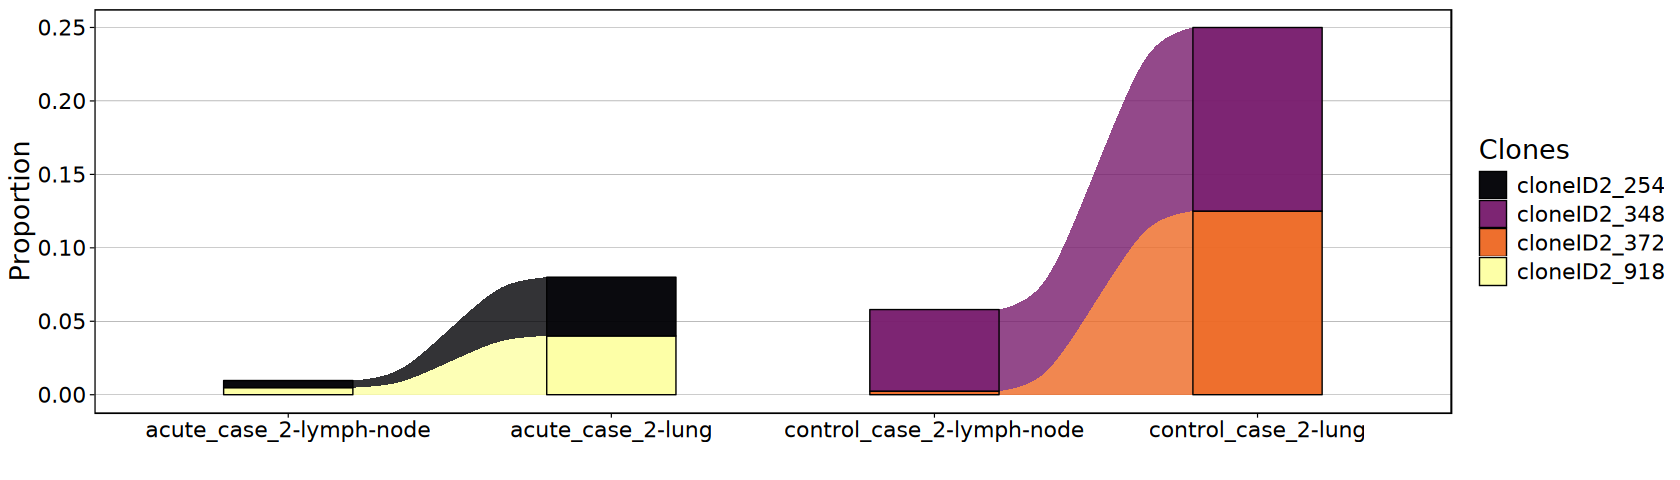

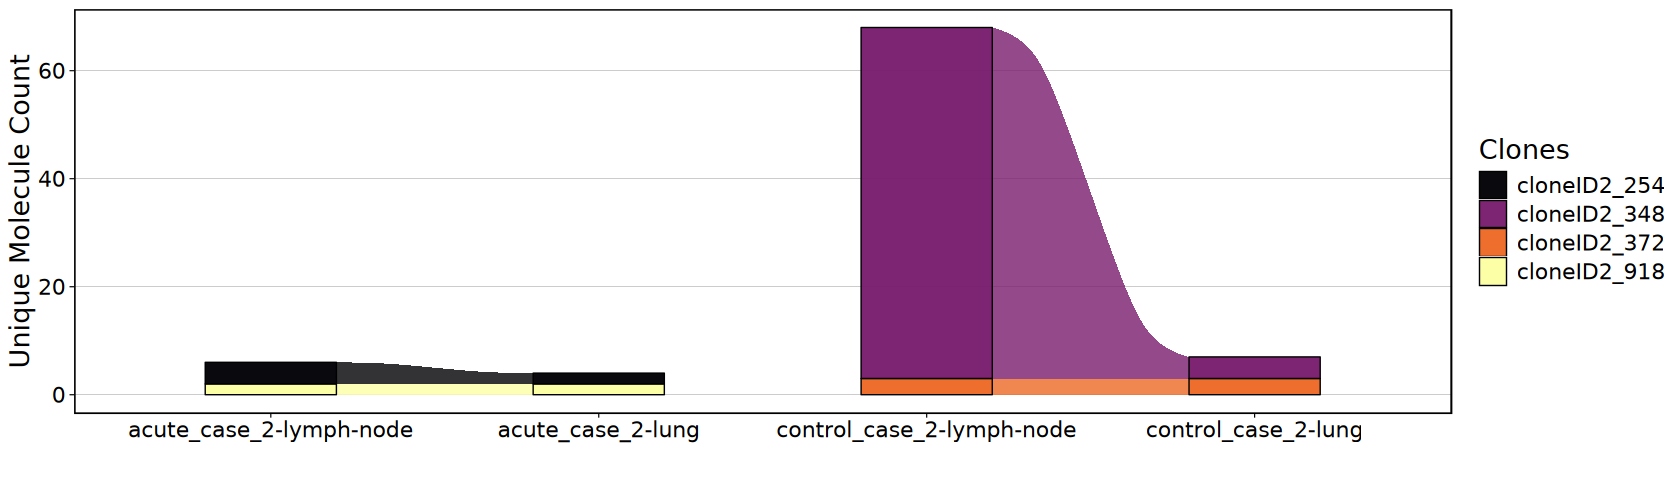

In [18]:
options(repr.plot.width = 14, repr.plot.height = 4, warn = -1)

tcr_df %>%
    group_by(condition, cloneID2) %>%
    mutate(n_tissues = n_distinct(tissue)) %>%
    ungroup() %>%
    filter(n_tissues > 1) %>%
    group_by(cond_tissue, cloneID2) %>%
    summarise(count = n(), .groups = "drop") %>%
    left_join(tcr_df %>% 
              group_by(cond_tissue) %>% 
              summarise(total = n(), .groups = "drop"),
              by = "cond_tissue") %>%
    mutate(value = count / total) %>%
    select(-count, -total) %>%
    mutate(condition = sub("_.*", "", cond_tissue),
           tissue = sub(".*_", "", cond_tissue)) %>%
    mutate(cond_tissue = factor(cond_tissue, levels = c("acute_case_2-lymph-node", "acute_case_2-lung", "control_case_2-lymph-node" ,"control_case_2-lung"))) %>%
    
    ggplot(aes(x = cond_tissue, y = value, stratum = cloneID2,  alluvium = cloneID2, fill = cloneID2)) +
    geom_alluvium(alpha = 0.8, width = 0.4) +
    geom_stratum(alpha = 0.8, color = "black", linewidth = 0.3, width = 0.4) +
    scale_fill_viridis_d(option = "inferno", name = "Clones") +
    labs(x = "", y = "Proportion") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          axis.text.x = element_text(hjust = 0.5),
          plot.title = element_text(hjust = 0.5, face = "bold"),
          panel.grid.major.x = element_blank(),
          panel.grid.minor = element_blank(),
          legend.position = "right")

###

tcr_df %>%
    group_by(condition, cloneID2) %>%
    mutate(n_tissues = n_distinct(tissue)) %>%
    ungroup() %>%
    filter(n_tissues > 1) %>%
    group_by(cond_tissue, cloneID2) %>%
    summarise(value = sum(uniqueMoleculeCount), .groups = "drop") %>%
    mutate(condition = sub("_.*", "", cond_tissue),
           tissue = sub(".*_", "", cond_tissue)) %>%
    mutate(cond_tissue = factor(cond_tissue, levels = c("acute_case_2-lymph-node", "acute_case_2-lung", "control_case_2-lymph-node", "control_case_2-lung"))) %>%
    
    ggplot(aes(x = cond_tissue, y = value, stratum = cloneID2, alluvium = cloneID2, fill = cloneID2)) +
    geom_alluvium(alpha = 0.8, width = 0.4) +
    geom_stratum(alpha = 0.8, color = "black", linewidth = 0.3, width = 0.4) +
    scale_fill_viridis_d(option = "inferno", name = "Clones") +
    labs(x = "", y = "Unique Molecule Count") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          axis.text.x = element_text(hjust = 0.5),
          plot.title = element_text(hjust = 0.5, face = "bold"),
          panel.grid.major.x = element_blank(),
          panel.grid.minor = element_blank(),
          legend.position = "right")

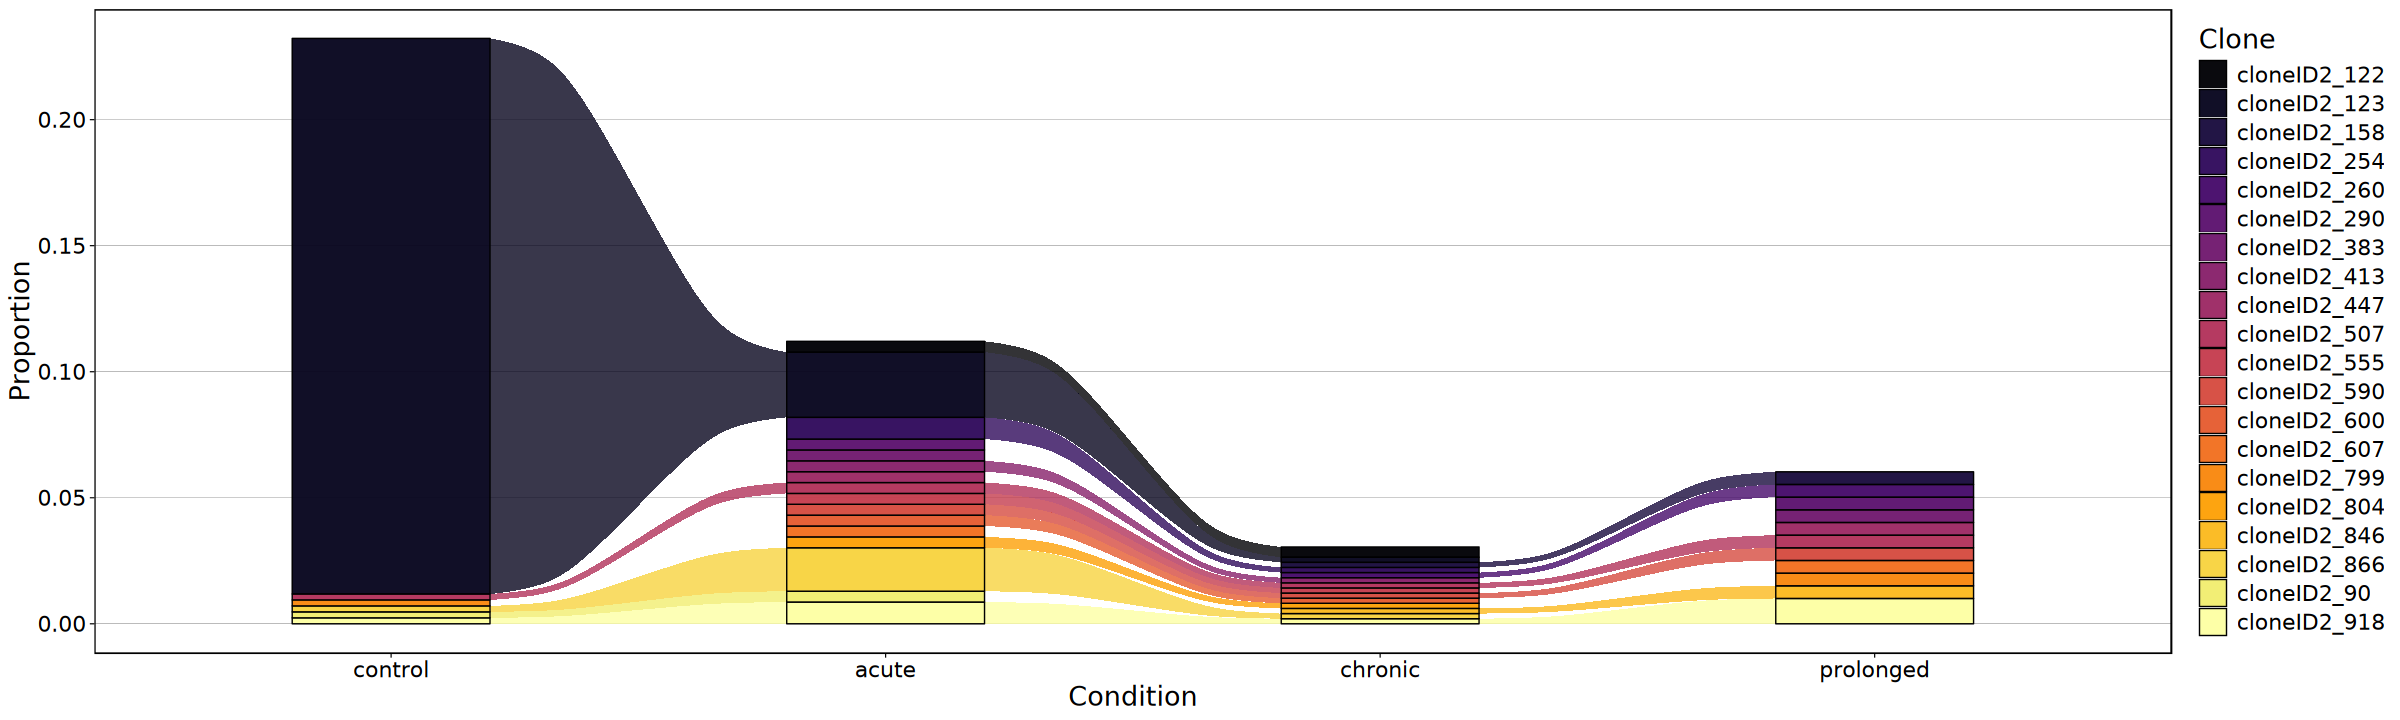

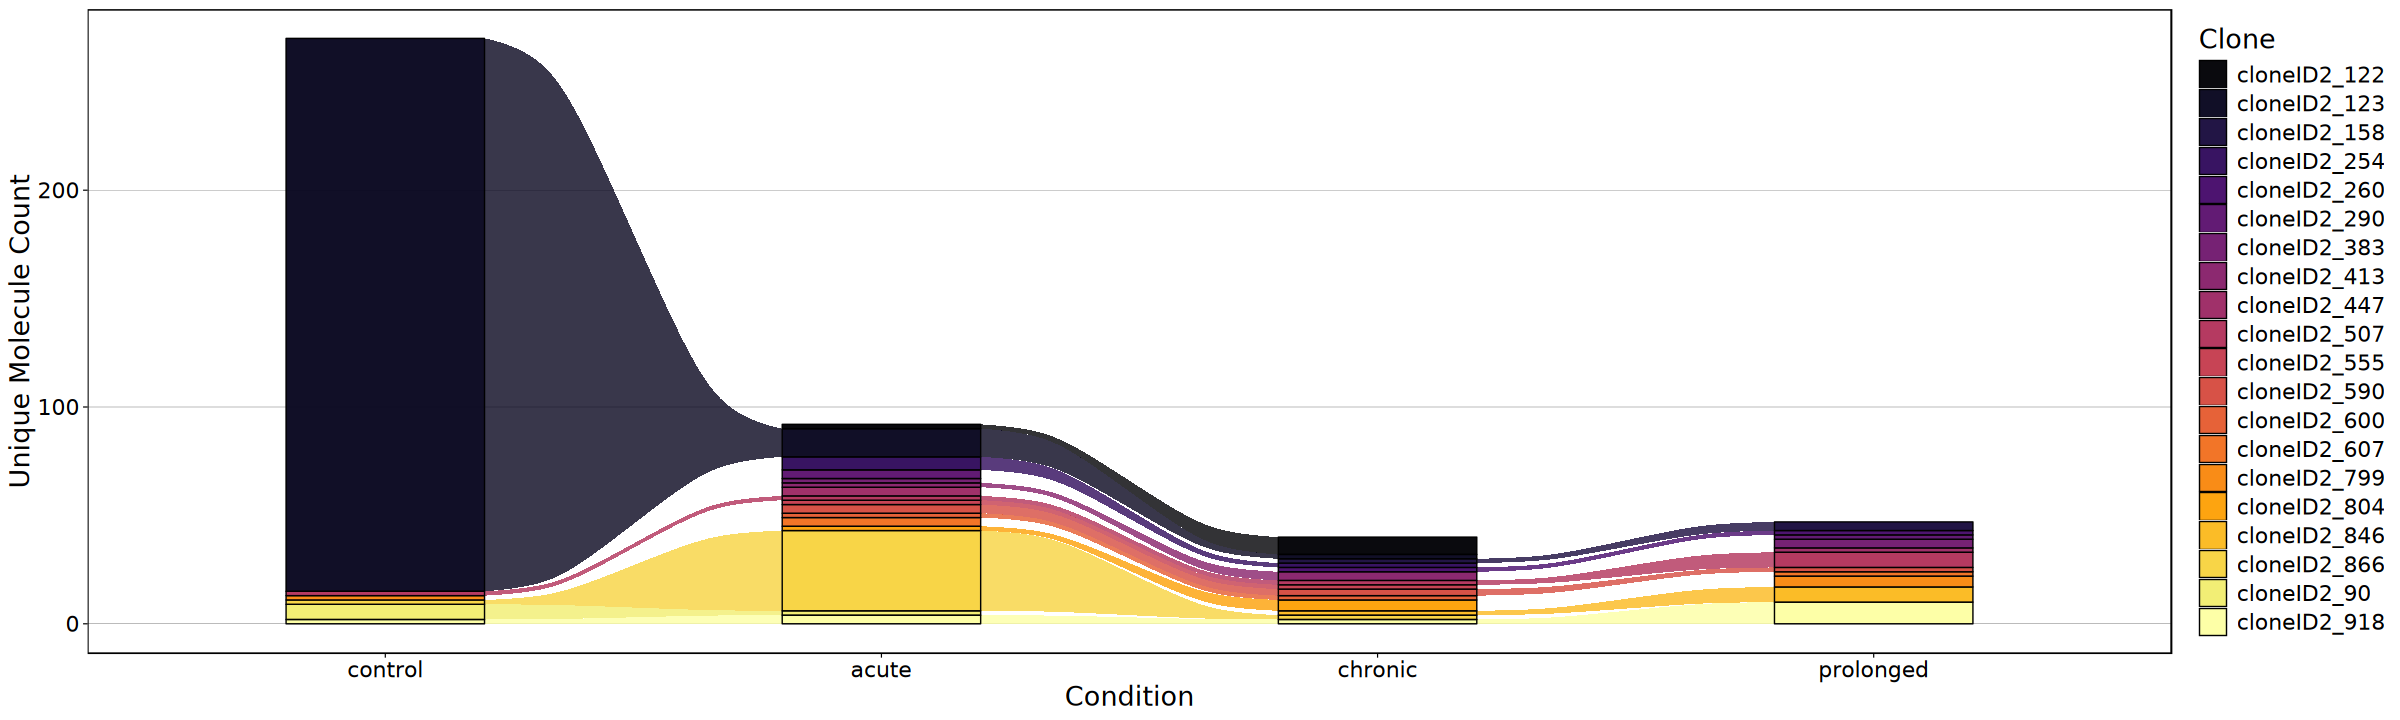

In [19]:
options(repr.plot.width = 20, repr.plot.height = 6, warn = -1)

tcr_df %>%
    group_by(cloneID2) %>%
    mutate(n_conditions = n_distinct(condition)) %>%
    ungroup() %>%
    filter(n_conditions > 1) %>%
    group_by(condition, cloneID2) %>%
    summarise(count = n(), .groups = "drop") %>%
    left_join(tcr_df %>% 
              group_by(condition) %>% 
              summarise(total = n(), .groups = "drop"),
              by = "condition") %>%
    mutate(value = count / total) %>%
    select(-count, -total) %>%
    mutate(condition = factor(condition, levels = c("control", "acute", "chronic", "prolonged"))) %>%

    ggplot(aes(x = condition, y = value, stratum = cloneID2, alluvium = cloneID2, fill = cloneID2)) +
    geom_alluvium(alpha = 0.8, width = 0.4) +
    geom_stratum(alpha = 0.8, color = "black", linewidth = 0.3, width = 0.4) +
    scale_fill_viridis_d(option = "inferno", name = "Clone") +
    labs(x = "Condition", y = "Proportion") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          axis.text.x = element_text(hjust = 0.5),
          plot.title = element_text(hjust = 0.5, face = "bold"),
          panel.grid.major.x = element_blank(),
          panel.grid.minor = element_blank(),
          legend.position = "right")

###

tcr_df %>%
    group_by(cloneID2) %>%
    mutate(n_conditions = n_distinct(condition)) %>%
    ungroup() %>%
    filter(n_conditions > 1) %>%
    group_by(condition, cloneID2) %>%
    summarise(value = sum(uniqueMoleculeCount), .groups = "drop") %>%
    mutate(condition = factor(condition, levels = c("control", "acute", "chronic", "prolonged"))) %>%
  
    ggplot(aes(x = condition, y = value, stratum = cloneID2, alluvium = cloneID2, fill = cloneID2)) +
    geom_alluvium(alpha = 0.8, width = 0.4) +
    geom_stratum(alpha = 0.8, color = "black", linewidth = 0.3, width = 0.4) +
    scale_fill_viridis_d(option = "inferno", name = "Clone") +
    labs(x = "Condition", y = "Unique Molecule Count") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          axis.text.x = element_text(hjust = 0.5),
          plot.title = element_text(hjust = 0.5, face = "bold"),
          panel.grid.major.x = element_blank(),
          panel.grid.minor = element_blank(),
          legend.position = "right")

We can also track clones defined by the amino acid CDR3 sequence, as amino-acid–level grouping captures functionally similar TCRs that are likely to recognize the same antigens, even when they originate from independent recombination events. This approach enables the identification of functionally similar TCRs that recur across tissues or conditions.

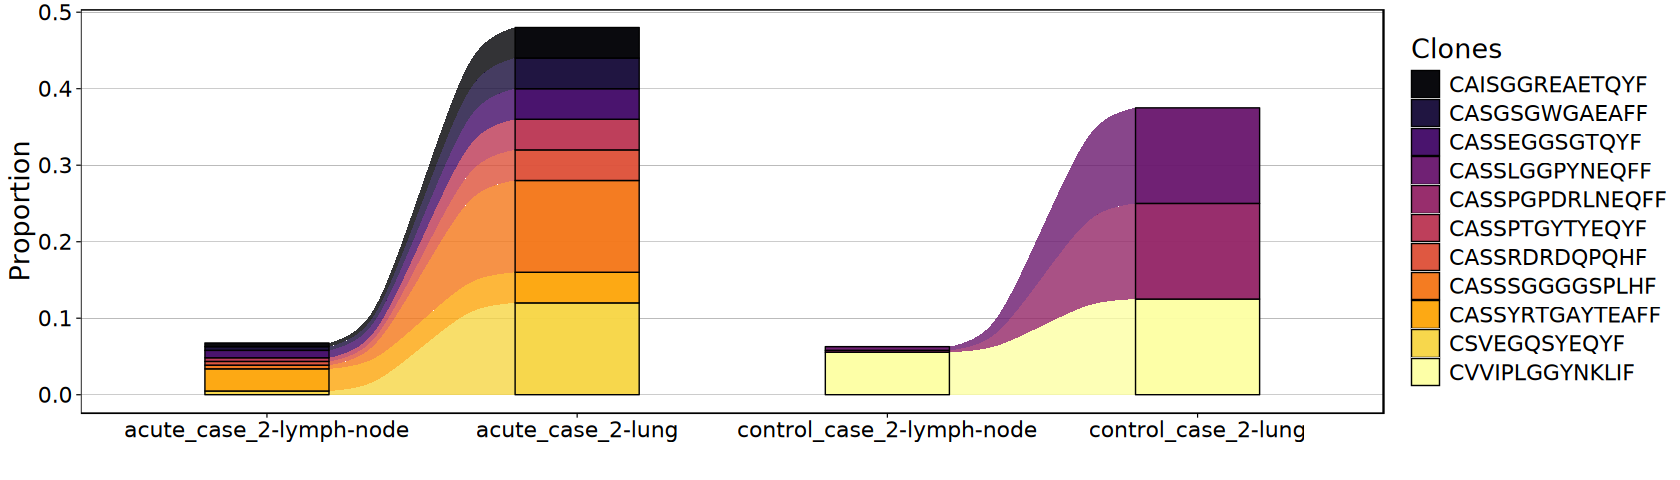

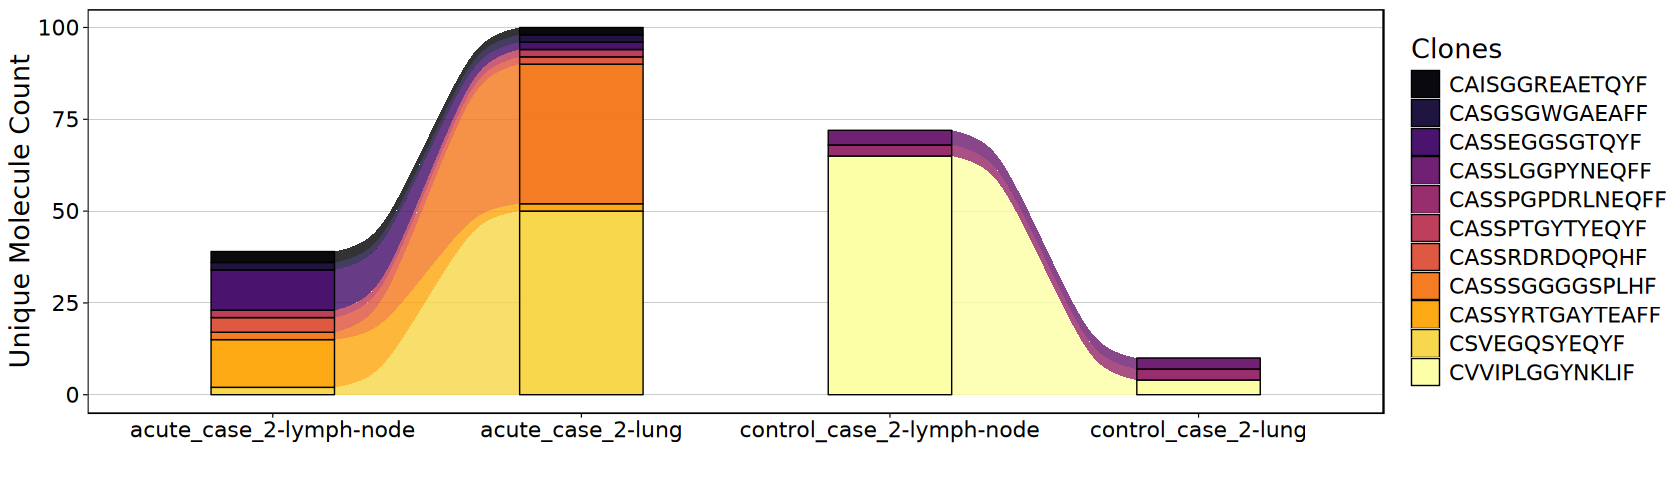

In [20]:
options(repr.plot.width = 14, repr.plot.height = 4, warn = -1)

tcr_df %>%
    group_by(condition, aaSeqCDR3) %>%
    mutate(n_tissues = n_distinct(tissue)) %>%
    ungroup() %>%
    filter(n_tissues > 1) %>%
    group_by(cond_tissue, aaSeqCDR3) %>%
    summarise(count = n(), .groups = "drop") %>%
    left_join(tcr_df %>% 
              group_by(cond_tissue) %>% 
              summarise(total = n(), .groups = "drop"),
              by = "cond_tissue") %>%
    mutate(value = count / total) %>%
    select(-count, -total) %>%
    mutate(condition = sub("_.*", "", cond_tissue),
           tissue = sub(".*_", "", cond_tissue)) %>%
    mutate(cond_tissue = factor(cond_tissue, levels = c("acute_case_2-lymph-node", "acute_case_2-lung", "control_case_2-lymph-node" ,"control_case_2-lung"))) %>%
  
    ggplot(aes(x = cond_tissue, y = value, stratum = aaSeqCDR3, alluvium = aaSeqCDR3, fill = aaSeqCDR3)) +
    geom_alluvium(alpha = 0.8, width = 0.4) +
    geom_stratum(alpha = 0.8, color = "black", linewidth = 0.3, width = 0.4) +
    scale_fill_viridis_d(option = "inferno", name = "Clones") +
    labs(x = "", y = "Proportion") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          axis.text.x = element_text(hjust = 0.5),
          plot.title = element_text(hjust = 0.5, face = "bold"),
          panel.grid.major.x = element_blank(),
          panel.grid.minor = element_blank(),
          legend.position = "right")

###

tcr_df %>%
    group_by(condition, aaSeqCDR3) %>%
    mutate(n_tissues = n_distinct(tissue)) %>%
    ungroup() %>%
    filter(n_tissues > 1) %>%
    group_by(cond_tissue, aaSeqCDR3) %>%
    summarise(value = sum(uniqueMoleculeCount), .groups = "drop") %>%
    mutate(condition = sub("_.*", "", cond_tissue),
           tissue = sub(".*_", "", cond_tissue)) %>%
    mutate(cond_tissue = factor(cond_tissue, levels = c("acute_case_2-lymph-node", "acute_case_2-lung", "control_case_2-lymph-node", "control_case_2-lung"))) %>%
    
    ggplot(aes(x = cond_tissue, y = value, stratum = aaSeqCDR3, alluvium = aaSeqCDR3, fill = aaSeqCDR3)) +
    geom_alluvium(alpha = 0.8, width = 0.4) +
    geom_stratum(alpha = 0.8, color = "black", linewidth = 0.3, width = 0.4) +
    scale_fill_viridis_d(option = "inferno", name = "Clones") +
    labs(x = "", y = "Unique Molecule Count") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          axis.text.x = element_text(hjust = 0.5),
          plot.title = element_text(hjust = 0.5, face = "bold"),
          panel.grid.major.x = element_blank(),
          panel.grid.minor = element_blank(),
          legend.position = "right")

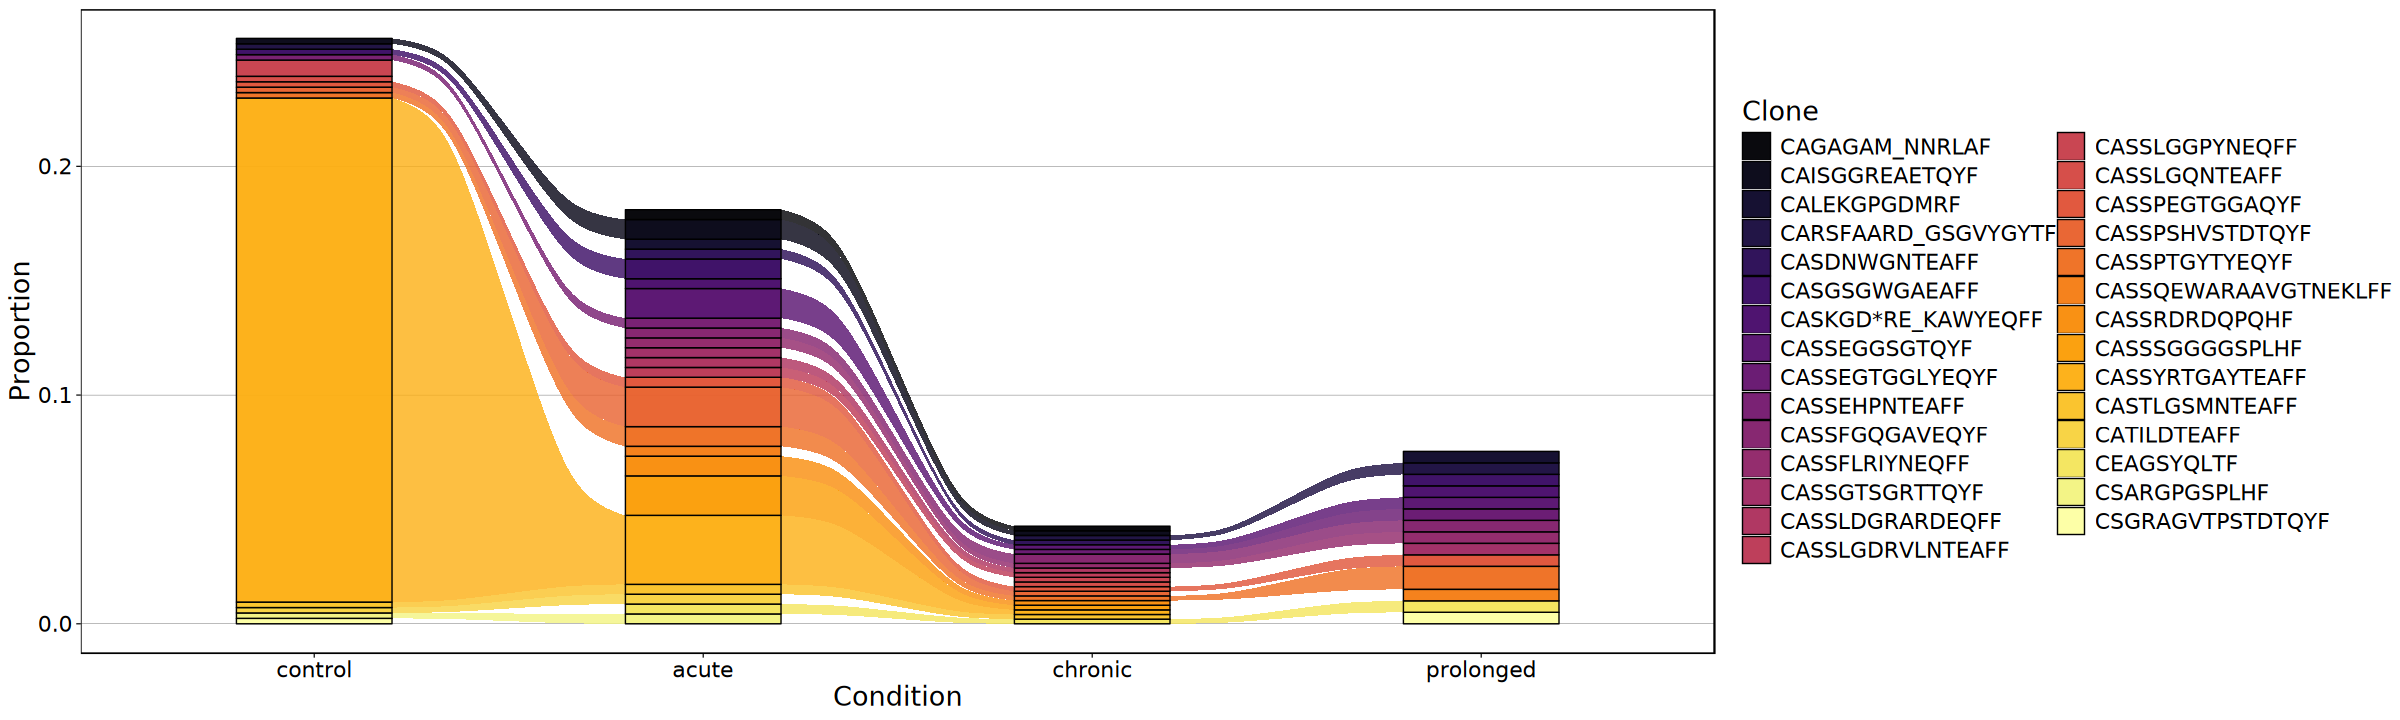

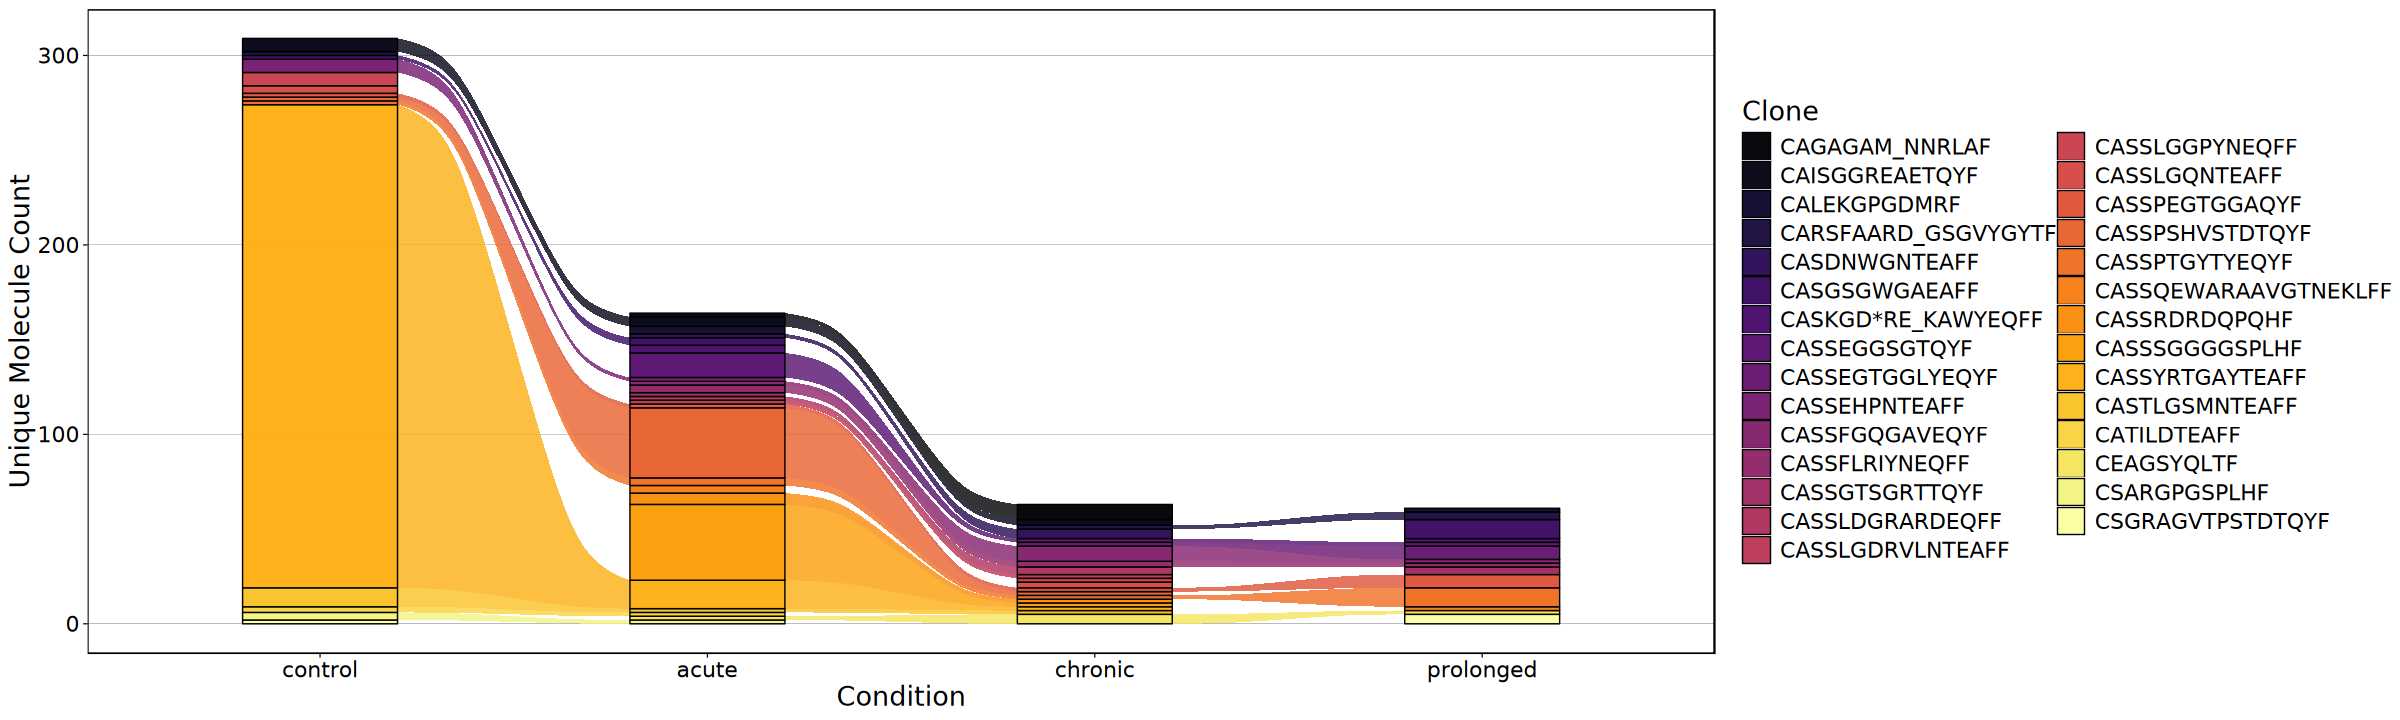

In [21]:
options(repr.plot.width = 20, repr.plot.height = 6, warn = -1)

tcr_df %>%
    group_by(aaSeqCDR3) %>%
    mutate(n_conditions = n_distinct(condition)) %>%
    ungroup() %>%
    filter(n_conditions > 1) %>%
    group_by(condition, aaSeqCDR3) %>%
    summarise(count = n(), .groups = "drop") %>%
    left_join(tcr_df %>% 
              group_by(condition) %>% 
              summarise(total = n(), .groups = "drop"),
              by = "condition") %>%
    mutate(value = count / total) %>%
    select(-count, -total) %>%
    mutate(condition = factor(condition, levels = c("control", "acute", "chronic", "prolonged"))) %>%

    ggplot(aes(x = condition, y = value, stratum = aaSeqCDR3, alluvium = aaSeqCDR3, fill = aaSeqCDR3)) +
    geom_alluvium(alpha = 0.8, width = 0.4) +
    geom_stratum(alpha = 0.8, color = "black", linewidth = 0.3, width = 0.4) +
    scale_fill_viridis_d(option = "inferno", name = "Clone") +
    labs(x = "Condition", y = "Proportion") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          axis.text.x = element_text(hjust = 0.5),
          plot.title = element_text(hjust = 0.5, face = "bold"),
          panel.grid.major.x = element_blank(),
          panel.grid.minor = element_blank(),
          legend.position = "right")

###

tcr_df %>%
    group_by(aaSeqCDR3) %>%
    mutate(n_conditions = n_distinct(condition)) %>%
    ungroup() %>%
    filter(n_conditions > 1) %>%
    group_by(condition, aaSeqCDR3) %>%
    summarise(value = sum(uniqueMoleculeCount), .groups = "drop") %>%
    mutate(condition = factor(condition, levels = c("control", "acute", "chronic", "prolonged"))) %>%
  
    ggplot(aes(x = condition, y = value, stratum = aaSeqCDR3, alluvium = aaSeqCDR3, fill = aaSeqCDR3)) +
    geom_alluvium(alpha = 0.8, width = 0.4) +
    geom_stratum(alpha = 0.8, color = "black", linewidth = 0.3, width = 0.4) +
    scale_fill_viridis_d(option = "inferno", name = "Clone") +
    labs(x = "Condition", y = "Unique Molecule Count") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          axis.text.x = element_text(hjust = 0.5),
          plot.title = element_text(hjust = 0.5, face = "bold"),
          panel.grid.major.x = element_blank(),
          panel.grid.minor = element_blank(),
          legend.position = "right")

## Clonotype frequencies (>2 spots)¶

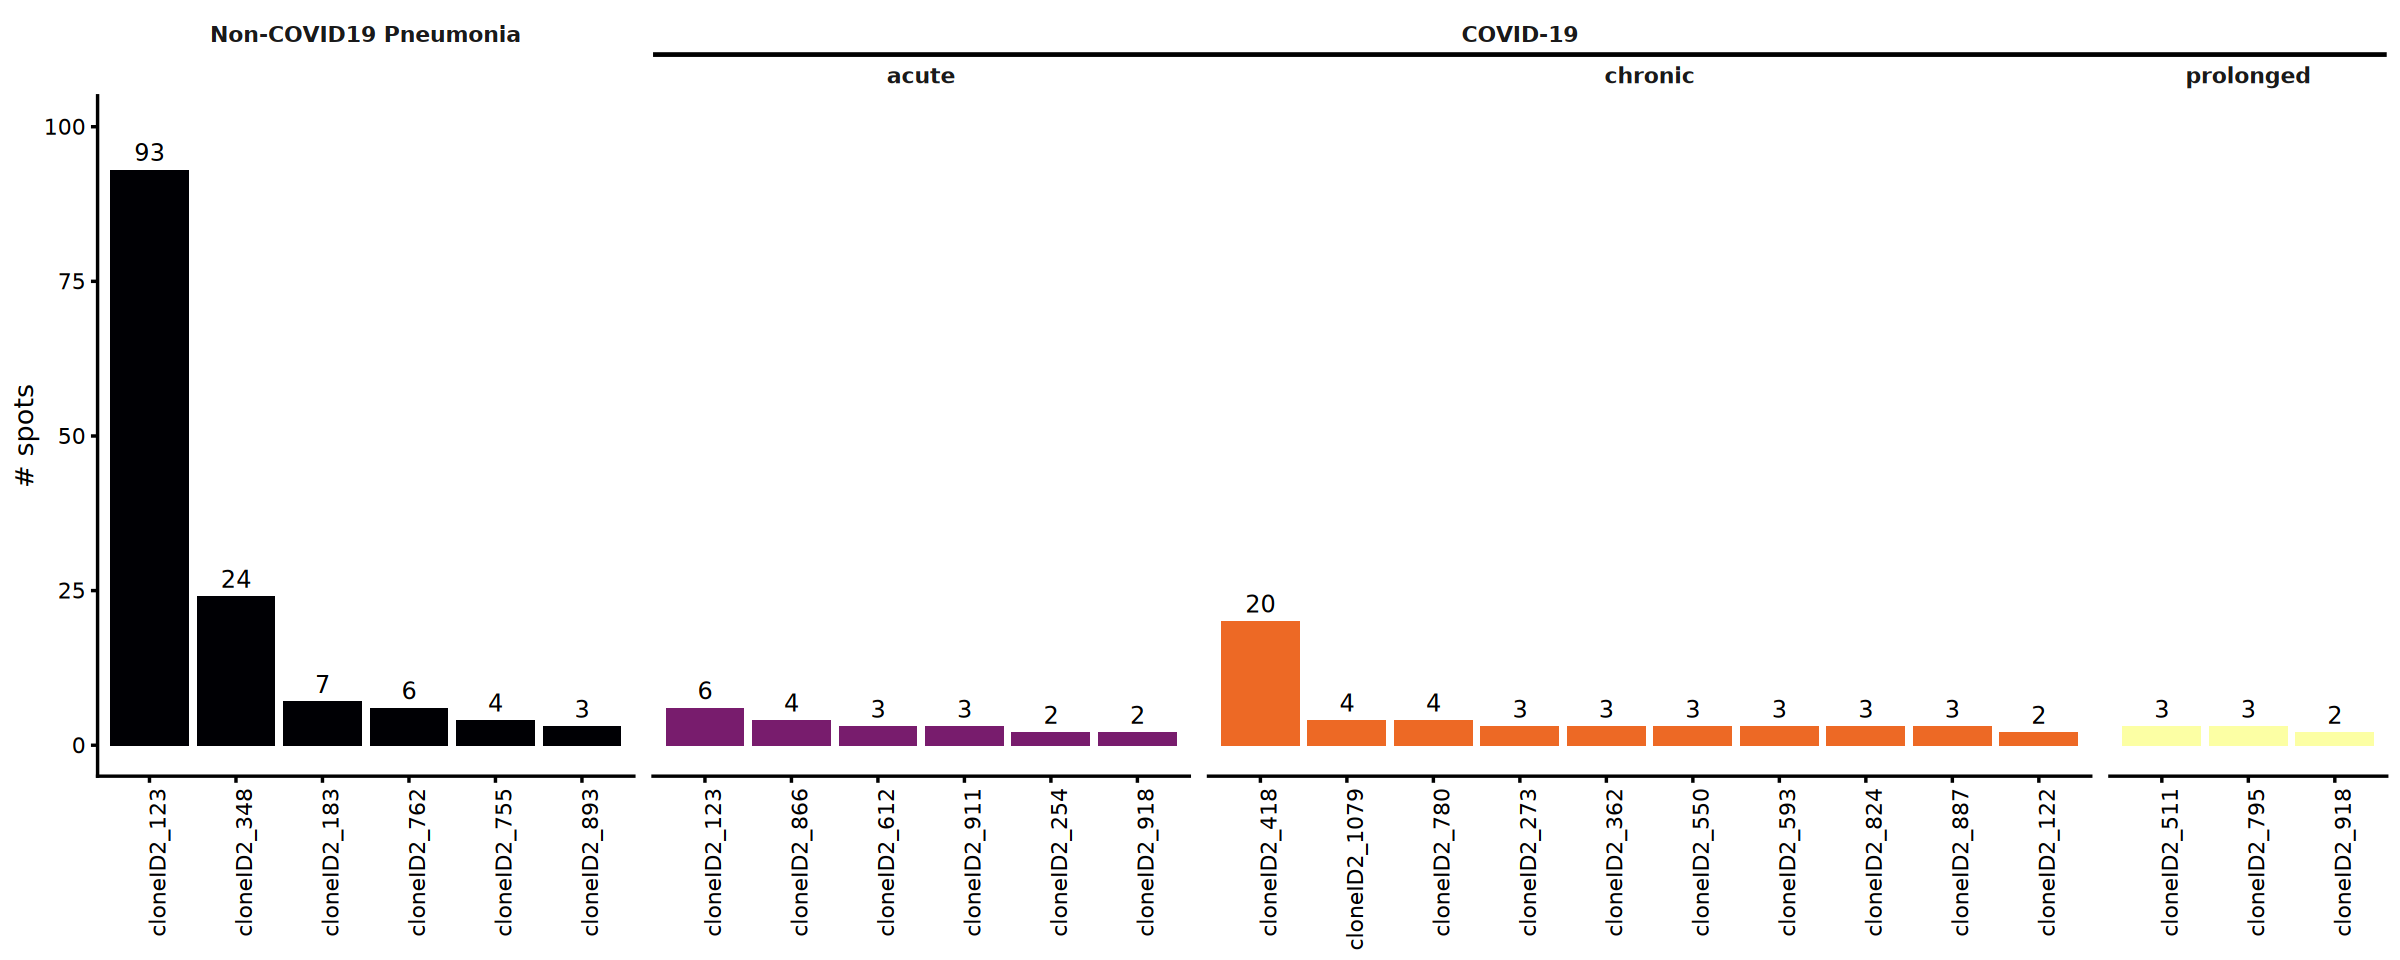

In [22]:
options(repr.plot.width = 20, repr.plot.height = 8, warn = -1)

tcr_df %>%
  filter(!is.na(cloneID2), !is.na(condition)) %>%
  group_by(cloneID2) %>%
  mutate(total_spots = n()) %>%
  filter(total_spots > 2) %>%
  group_by(cloneID2, condition) %>%
  filter(n() >= 2) %>%  
  ungroup() %>%
  group_by(cloneID2, condition, total_spots) %>%
  summarise(freq = n(), .groups = "drop") %>%
  arrange(condition, desc(total_spots)) %>%
  mutate(condition = factor(condition,
                            levels = c("control", "acute", "chronic", "prolonged")),
         disease_group = ifelse(condition == "control", "Non-COVID19 Pneumonia", "COVID-19"),
         disease_group = factor(disease_group, levels = c("Non-COVID19 Pneumonia", "COVID-19")),
         cloneID2 = reorder_within(cloneID2, -freq, condition)) %>%
  
  ggplot(aes(x = cloneID2, y = freq, fill = condition)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = freq), vjust = -0.5, size = 5) +
  ggh4x::facet_nested(~ disease_group + condition,
                      scales = "free_x", space = "free_x",
                      labeller = labeller(
                        condition = c("control" = "", "acute" = "acute",
                                    "chronic" = "chronic", "prolonged" = "prolonged"))) +
  coord_cartesian(ylim = c(0, 100)) +
  scale_x_reordered() +
  scale_fill_manual(values = viridis::inferno(4)) +
  labs(y = "# spots", x = NULL) +
  theme_classic(base_size = 16) +
  theme(strip.background = element_blank(),
        strip.text = element_text(face = "bold"),
        ggh4x.facet.nestline = element_line(linewidth = 1),
        legend.position = "none",
        axis.text.x = element_text(angle = 90, hjust = 1),
        panel.spacing = unit(0.8, "lines"))

# Session information

In [23]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/groups/singlecell/cvicente/miniconda3/envs/COVID/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] viridis_0.6.5       viridisLite_0.4.3   ggh4x_0.3.1        
 [4] ggalluvial_0.12.6   patchwork_1.3.2     Biostrings_2.78.0  
 [7] Seqinfo_1.0.0       XVector_0.50.0      IRanges_2.44.0     
[1